In [5]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study5.0Pilot3'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/Plots/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
outputdirCleaned = os.path.join(topdir, f'data/{study}/Cleaned')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'stripes_low', 'stripes_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'stripes_discrete_slider.response', 'stripes_direction_slider.response', 'stripes_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_stripes', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'cogpro_predict', 'cogpro_explain', 'relevant_dim', 'irrelevant_

Data Processing (fix string representations of lists)

In [6]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_stripes', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [49]:
print("Attention check failures by condition:")

for name, df in [('Accommodate', df_accommodate), ('Predict', df_predict)]:
    n_failed = (df['attention_check'] == 0).sum()
    n_total = len(df)
    print(f"{name}: {n_failed}/{n_total} failed")

# Remove attention check failures
df_accommodate_clean = df_accommodate[df_accommodate['attention_check'] == 1].copy()
df_predict_clean = df_predict[df_predict['attention_check'] == 1].copy()

# Recombine
df_combined = pd.concat([df_accommodate_clean, df_predict_clean], ignore_index=True)

# Recreate participant IDs
df_combined['participant'] = range(1, len(df_combined) + 1)

print(df_combined['task'].value_counts())

Attention check failures by condition:
Accommodate: 10/42 failed
Predict: 7/41 failed
task
predict        34
accommodate    32
Name: count, dtype: int64


In [7]:
feedback_by_condition = (
    df_combined
    .loc[df_combined['feedback'].notna(), ['task', 'participant', 'feedback']]
    .sort_values(['task', 'participant'])
)

for task, sub in feedback_by_condition.groupby('task'):
    print(f"\n\n=== {task.upper()} ===")
    for _, row in sub.iterrows():
        print(f"\nParticipant {row['participant']}:")
        print(row['feedback'])



=== ACCOMMODATE ===

Participant 1:
[]

Participant 2:
["It's a matter of which trait was visible and how it affected the score. With any kind of genetics, there is always an affect based upon on how well expressed the trait is. That is why the angling of the stripes right or left played a smaller role in the fertility score, but it's presence still affected it. As for the feet, webbing was important to have or not have, as the curly feet definitely seemed to have a negative affect on the fertility score."]

Participant 3:
[]

Participant 4:
[]

Participant 5:
[]

Participant 6:
['I looked at the stripe direction and feet and tried to see if any were associated with higher scores.']

Participant 7:
['I made the decisions according to some features i observed']

Participant 8:
['I enjoyed this survey, I realized in the end that I didn’t realize certain small details that changed but made a huge difference\xa0']

Participant 9:
[]

Participant 10:
[]

Participant 11:
['It took a while 

In [8]:
accommodator_texts = (
    df_combined[df_combined['task'] == 'accommodate']['free_texts']
)

for i, texts in enumerate(accommodator_texts, 1):
    if isinstance(texts, str):
        texts = parse_list_column(texts)
    
    if texts:  # skip empty responses
        print(f"\n=== Accommodator {i} ===")
        for response in texts:
            print(response)


=== Accommodator 1 ===
Has webbed legs and strippd body that help it fit in the environment properly.
Based on its color, the reptile was a bit less fertile because of the environment issues, the season was not friendly
The season was getting somehow better hence favourable.
The skin color looks weak, the season was harsh thus poor fertility rate
The legs are more webbed proving that the season was doing better thus high fertility rate.
The season was very unfavorable
Has webbed legs hence average fertility rate
Has webbed legs hence average fertility rate

=== Accommodator 2 ===
This reptile may be more fertile because they have webbed feet and stripes angled to the right.
The presence of the stripes angles left may be contributing to a slightly more fertility score, possibly along with having webbed feet.
The presence of curly feet may be lowering the fertility score
The presence of curly feet is again lowering the fertility score
The presence of webbed feet and left angled stripes 

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/942694789.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/942694789.py:26: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


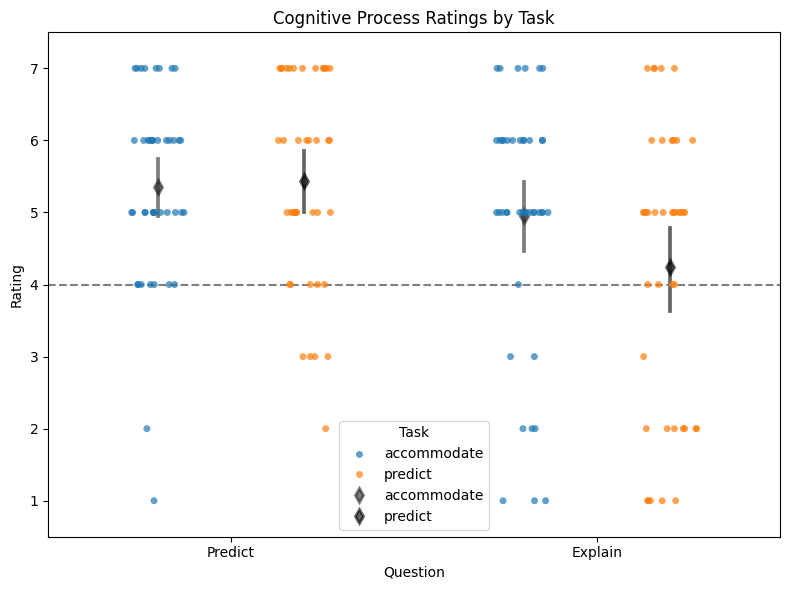

In [9]:

# long format for plotting
df_cogpro_long = df_combined.melt(
    id_vars=['participant', 'task'],
    value_vars=['cogpro_predict', 'cogpro_explain'],
    var_name='question',
    value_name='rating'
)

df_cogpro_long['question'] = df_cogpro_long['question'].replace({
    'cogpro_predict': 'Predict',
    'cogpro_explain': 'Explain'
})

plt.figure(figsize=(8,6))

sns.stripplot(
    data=df_cogpro_long,
    x='question',
    y='rating',
    hue='task',
    dodge=True,
    jitter=.15,
    alpha=.7
)

sns.pointplot(
    data=df_cogpro_long,
    x='question',
    y='rating',
    hue='task',
    dodge=.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.6
)

plt.ylim(.5, 7.5)
plt.axhline(4, color='gray', linestyle='--')
plt.title('Cognitive Process Ratings by Task')
plt.ylabel('Rating')
plt.xlabel('Question')
plt.legend(title='Task')
plt.tight_layout()

plt.savefig(os.path.join(outputdir, 'CogProRatingsByTask.png'), dpi=300)
plt.show()

In [10]:
#Look at fertility score in training by participant/category in accomodate task
df = df_accommodate[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high         7.44186
1      low        3.604651


In [11]:
#Look at fertility score in training by participant/category in predict task
df = df_predict[['participant', 'training_categories', 'fertility_score']]
df_long = (
    df
    .explode(['training_categories', 'fertility_score'])
    .rename(columns={'training_categories': 'category'})
)
avg_fertility = (
    df_long
    .groupby(['category'], as_index=False)
    ['fertility_score']
    .mean()
)
print(avg_fertility)

  category fertility_score
0     high        7.493902
1      low        3.615854


In [12]:
#Overall means by category in accommodate task (participant responses)
df = df_accommodate[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high          6.511628
1      low          5.593023


In [13]:
#Overall means by actual testing category in prediction task
df = df_predict[['participant', 'testing_categories', 'testing_responses']]
df_long = (
    df
    .explode(['testing_categories', 'testing_responses'])
    .rename(columns={'testing_categories': 'category'})
)
#print(df_long)
avg_rating = (
    df_long
    .groupby(['category'], as_index=False)
    ['testing_responses']
    .mean()
)
print(avg_rating)

  category testing_responses
0     high          6.646341
1      low          5.085366


Timing

task
accommodate    513.435670
predict        326.075683
Name: trial_stop_time, dtype: float64


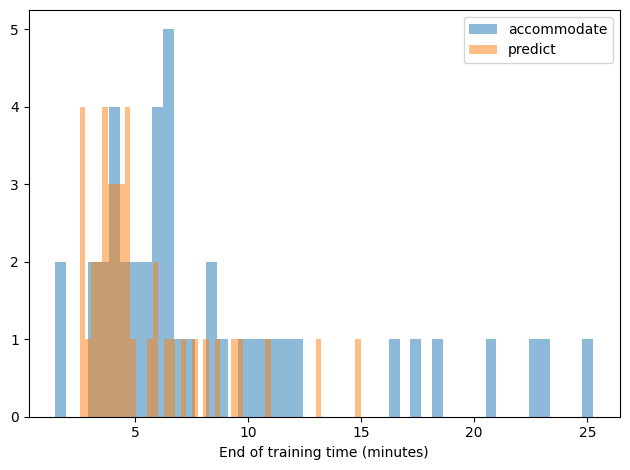

In [14]:
#Look at average time across task
df_combined['trial_stop_time'].describe()
avg_time = df_combined.groupby(['task'])['trial_stop_time'].mean()
print(avg_time)

for task, subdf in df_combined.groupby('task'):
    plt.hist(
        subdf['trial_stop_time']/60,
        bins=50,
        alpha=0.5,
        label=task
    )

plt.xlabel('End of training time (minutes)')
plt.legend()
plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure1TrialStopTimeByTask.png'))
plt.show()


**Primary Analysis #1**

Part 1: Model Parameter Score Complexity across conditions

In [15]:
import pandas as pd
from scipy.stats import chi2_contingency

participant_rows = []

for _, row in df_combined.iterrows():
    feet_yes = 1 if str(row['feet_discrete_slider.response']).strip() == 'Yes' else 0
    stripes_yes = 1 if str(row['stripes_discrete_slider.response']).strip() == 'Yes' else 0

    model_param_score = feet_yes + stripes_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],

        'relevant_dim': row['relevant_dim'],
        'irrelevant_dim': row['irrelevant_dim'],

        'feet_high': row['feet_high'],
        'stripes_high': row['stripes_high'],
        'feet_low': row['feet_low'],
        'stripes_low': row['stripes_low'],

        'feet_discrete_slider.response': row['feet_discrete_slider.response'],
        'stripes_discrete_slider.response': row['stripes_discrete_slider.response'],

        'feet_reported_relevant': feet_yes,
        'stripes_reported_relevant': stripes_yes,
        'cogpro_explain': row['cogpro_explain'],
        'cogpro_predict': row['cogpro_predict'],

        # overfit = selected both dimensions
        'overfit': model_param_score == 2
    })

df_params = pd.DataFrame(participant_rows)

contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate     13     30
predict         19     22
Chi-square = 1.677
df = 1
p-value = 0.1953


          task irrelevant_dim      mean  sum  count  overfit_percent
0  accommodate           feet  0.714286   15     21        71.428571
1  accommodate        stripes  0.681818   15     22        68.181818
2      predict           feet  0.619048   13     21        61.904762
3      predict        stripes  0.450000    9     20        45.000000


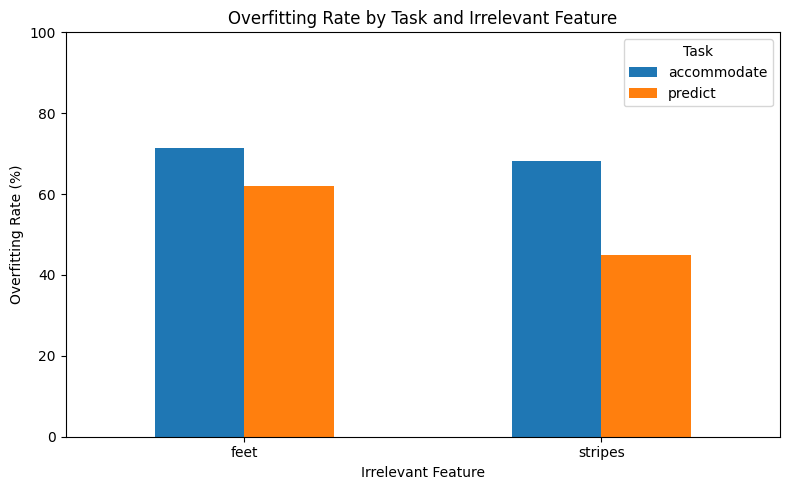

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Overfitting rate by task and irrelevant feature
overfit_summary = (
    df_params
    .groupby(['task', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

# Convert mean proportion to percent
overfit_summary['overfit_percent'] = overfit_summary['mean'] * 100

print(overfit_summary)

#Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Pivot for plot
plot_data = overfit_summary.pivot(
    index='irrelevant_dim',
    columns='task',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Task and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='Task')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure2OverfittingRateByTask.png'))
plt.show()

In [17]:
df_plot = df_long.merge(
    df_params[['participant', 'overfit']],
    on='participant'
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=df_plot,
    x='feature_relevance',
    y='feature_importance',
    hue='overfit',
    col='task',
    kind='violin',
    inner='quartile',
    height=5,
    aspect=1
)

plt.show()

ValueError: Could not interpret value `feature_relevance` for `x`. An entry with this name does not appear in `data`.

In [86]:
irrelevant = (
    df_plot[df_plot['feature_relevance'] == 'irrelevant']
    .groupby(['task', 'irrelevant_dim'])
    ['feature_importance']
    .describe()
)

print(irrelevant)

                            count      mean       std  min   25%  50%   75%  \
task        irrelevant_dim                                                    
accommodate feet             22.0  0.909091  4.173717 -5.0 -3.75  0.0  5.00   
            stripes          20.0  1.300000  3.840230 -6.0  0.00  0.0  5.00   
predict     feet             21.0  1.047619  3.625965 -5.0  0.00  0.0  4.00   
            stripes          20.0  1.200000  3.981536 -6.0  0.00  0.0  5.25   

                            max  
task        irrelevant_dim       
accommodate feet            7.0  
            stripes         7.0  
predict     feet            7.0  
            stripes         7.0  


In [87]:
df_plot['endorsed'] = df_plot['feature_importance'] > 0

endorsement = (
    df_plot
    .groupby(['task','feature_relevance','feature_dimension'])
    ['endorsed']
    .mean()
    .reset_index()
)

print(endorsement)

          task feature_relevance feature_dimension  endorsed
0  accommodate        irrelevant              feet  0.454545
1  accommodate        irrelevant           stripes  0.400000
2  accommodate          relevant              feet  0.200000
3  accommodate          relevant           stripes  0.727273
4      predict        irrelevant              feet  0.428571
5      predict        irrelevant           stripes  0.400000
6      predict          relevant              feet  0.650000
7      predict          relevant           stripes  0.333333


In [88]:
wide = (
    df_plot
    .pivot_table(
        index=['participant','task','overfit','irrelevant_dim'],
        columns='feature_relevance',
        values='feature_importance'
    )
    .reset_index()
)

print(
    wide.groupby(
        ['task','irrelevant_dim','overfit']
    )[['relevant','irrelevant']].mean()
)

feature_relevance                   relevant  irrelevant
task        irrelevant_dim overfit                      
accommodate feet           False    1.888889    1.666667
                           True     6.000000    0.384615
            stripes        False    0.400000    0.733333
                           True     1.200000    3.000000
predict     feet           False    0.562500    0.187500
                           True     3.000000    3.800000
            stripes        False    1.818182    0.454545
                           True     5.222222    2.111111


In [90]:
pd.crosstab(
    df_params["overfit"],
    df_params["model_param_score"]
)
df_params.groupby(
    ["task","irrelevant_dim"]
)["model_param_score"].value_counts()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_27191/2873132086.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_params.groupby(


task         irrelevant_dim  model_param_score
predict      feet            1                    13
                             2                     5
                             0                     3
             stripes         2                     9
                             1                     7
                             0                     4
accommodate  feet            2                    13
                             1                     7
                             0                     2
             stripes         0                     8
                             1                     7
                             2                     5
Name: count, dtype: int64

In [95]:
df_binary = df_long.copy()

df_binary["endorsed"] = df_binary["feature_importance"].ne(0)

wide = (
    df_binary
    .pivot_table(
        index=["participant", "task", "relevant_dim", "irrelevant_dim"],
        columns="feature_relevance",
        values="endorsed",
        aggfunc="max"
    )
    .reset_index()
)

# make sure relevant/irrelevant are true booleans
wide["relevant"] = wide["relevant"].fillna(False).astype(bool)
wide["irrelevant"] = wide["irrelevant"].fillna(False).astype(bool)

wide["overfit"] = wide["relevant"] & wide["irrelevant"]
wide["underfit"] = ~wide["relevant"] & ~wide["irrelevant"]
wide["correct"] = wide["relevant"] & ~wide["irrelevant"]
wide["wrong_feature"] = ~wide["relevant"] & wide["irrelevant"]

summary = (
    wide
    .melt(
        id_vars=["participant", "task", "irrelevant_dim"],
        value_vars=["correct", "overfit", "underfit", "wrong_feature"],
        var_name="classification",
        value_name="value"
    )
    .query("value")
    .groupby(["task", "irrelevant_dim", "classification"])
    .size()
    .reset_index(name="n")
)

print(summary)

           task irrelevant_dim classification   n
0   accommodate           feet        correct   3
1   accommodate           feet        overfit  13
2   accommodate           feet       underfit   2
3   accommodate           feet  wrong_feature   4
4   accommodate        stripes        correct   1
5   accommodate        stripes        overfit   5
6   accommodate        stripes       underfit   8
7   accommodate        stripes  wrong_feature   6
8       predict           feet        correct   5
9       predict           feet        overfit   5
10      predict           feet       underfit   3
11      predict           feet  wrong_feature   8
12      predict        stripes        correct   4
13      predict        stripes        overfit   9
14      predict        stripes       underfit   4
15      predict        stripes  wrong_feature   3


          task irrelevant_dim      mean  sum  count  \
0      predict           feet  0.619048   13     21   
1      predict        stripes  0.600000   12     20   
2  accommodate           feet  0.772727   17     22   
3  accommodate        stripes  0.550000   11     20   

   percent_reported_irrelevant  
0                    61.904762  
1                    60.000000  
2                    77.272727  
3                    55.000000  


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_27191/451027472.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim'])['reported_relevant']


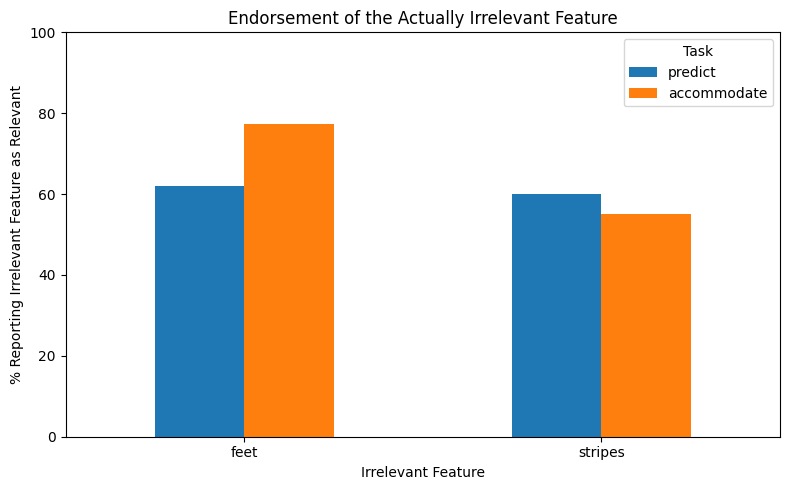

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Build long version of reported relevance
reported_long = df_params.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'overfit'],
    value_vars=[
        'feet_discrete_slider.response',
        'stripes_discrete_slider.response'
    ],
    var_name='reported_feature',
    value_name='reported_response'
)

# Clean feature names
reported_long['reported_feature'] = (
    reported_long['reported_feature']
    .str.replace('_discrete_slider.response', '', regex=False)
)

# Did participant say this feature mattered?
reported_long['reported_relevant'] = (
    reported_long['reported_response'].astype(str).str.strip().eq('Yes')
).astype(int)

# Is this feature actually irrelevant?
reported_long['is_irrelevant_feature'] = (
    reported_long['reported_feature'] == reported_long['irrelevant_dim']
)

# Keep only the actually irrelevant feature for each participant
irrelevant_reports = reported_long[reported_long['is_irrelevant_feature']].copy()

# Summarize: when feet vs stripes are irrelevant, how often was that irrelevant feature endorsed?
irrelevant_summary = (
    irrelevant_reports
    .groupby(['task', 'irrelevant_dim'])['reported_relevant']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

irrelevant_summary['percent_reported_irrelevant'] = irrelevant_summary['mean'] * 100

print(irrelevant_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = irrelevant_summary.pivot(
    index='irrelevant_dim',
    columns='task',
    values='percent_reported_irrelevant'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Endorsement of the Actually Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('% Reporting Irrelevant Feature as Relevant')
ax.set_ylim(0, 100)
ax.legend(title='Task')
plt.xticks(rotation=0)
plt.tight_layout()

#plt.savefig(os.path.join(outputdir, 'IrrelevantFeatureEndorsementByTask.png'))
plt.show()

          task relevant_dim      mean  count    percent
0      predict         feet  0.650000     20  65.000000
1      predict      stripes  0.476190     21  47.619048
2  accommodate         feet  0.300000     20  30.000000
3  accommodate      stripes  0.727273     22  72.727273


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_27191/699725889.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'relevant_dim'])['reported_relevant']


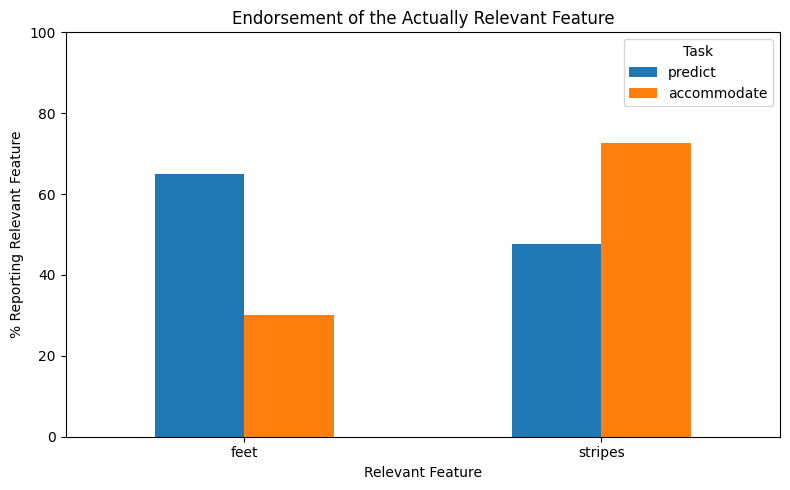

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Build long format
reported_long = df_params.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim'],
    value_vars=[
        'feet_discrete_slider.response',
        'stripes_discrete_slider.response'
    ],
    var_name='feature',
    value_name='response'
)

# Clean names
reported_long['feature'] = (
    reported_long['feature']
    .str.replace('_discrete_slider.response', '', regex=False)
)

# Binary endorsement
reported_long['reported_relevant'] = (
    reported_long['response'].astype(str).str.strip() == 'Yes'
).astype(int)

# Keep ONLY the actually relevant feature
relevant_reports = reported_long[
    reported_long['feature'] == reported_long['relevant_dim']
].copy()

# Summarize
relevant_summary = (
    relevant_reports
    .groupby(['task', 'relevant_dim'])['reported_relevant']
    .agg(['mean', 'count'])
    .reset_index()
)

relevant_summary['percent'] = relevant_summary['mean'] * 100

print(relevant_summary)
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = relevant_summary.pivot(
    index='relevant_dim',
    columns='task',
    values='percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Endorsement of the Actually Relevant Feature')
ax.set_xlabel('Relevant Feature')
ax.set_ylabel('% Reporting Relevant Feature')
ax.set_ylim(0, 100)
ax.legend(title='Task')

plt.xticks(rotation=0)
plt.tight_layout()

#plt.savefig(os.path.join(outputdir, 'RelevantFeatureEndorsementByTask.png'))
plt.show()


In [82]:
df_params['choice_type'] = df_params.apply(lambda row:
    'both' if (row['feet_reported_relevant'] == 1 and row['stripes_reported_relevant'] == 1)
    else 'feet_only' if row['feet_reported_relevant'] == 1
    else 'stripes_only' if row['stripes_reported_relevant'] == 1
    else 'none',
    axis=1
)

choice_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'choice_type'])
    .size()
    .reset_index(name='count')
)

choice_counts['percent'] = (
    choice_counts['count'] /
    choice_counts.groupby(['task', 'irrelevant_dim'])['count'].transform('sum')
    * 100
)

print(choice_counts)

           task irrelevant_dim   choice_type  count    percent
0       predict           feet          both      5  23.809524
1       predict           feet     feet_only      8  38.095238
2       predict           feet          none      3  14.285714
3       predict           feet  stripes_only      5  23.809524
4       predict        stripes          both      9  45.000000
5       predict        stripes     feet_only      4  20.000000
6       predict        stripes          none      4  20.000000
7       predict        stripes  stripes_only      3  15.000000
8   accommodate           feet          both     13  59.090909
9   accommodate           feet     feet_only      4  18.181818
10  accommodate           feet          none      2   9.090909
11  accommodate           feet  stripes_only      3  13.636364
12  accommodate        stripes          both      5  25.000000
13  accommodate        stripes     feet_only      1   5.000000
14  accommodate        stripes          none      8  40

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_27191/2152454525.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'choice_type'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_27191/2152454525.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  choice_counts.groupby(['task', 'irrelevant_dim'])['count'].transform('sum')


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_27191/2494727352.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_data = choice_counts.pivot_table(


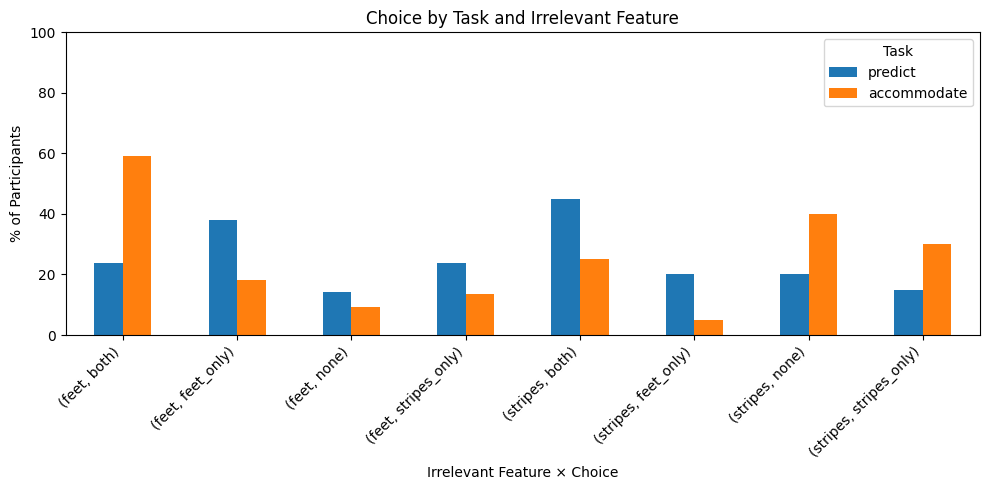

In [83]:
import matplotlib.pyplot as plt
import os

plot_data = choice_counts.pivot_table(
    index=['irrelevant_dim', 'choice_type'],
    columns='task',
    values='percent',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 5))

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Choice by Task and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature × Choice')
ax.set_ylabel('% of Participants')
ax.set_ylim(0, 100)
ax.legend(title='Task')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'ChoiceTypeByTaskAndIrrelevantFeature.png'))
plt.show()

In [62]:
import pandas as pd
import statsmodels.api as sm

# Reference levels
df_params = df_params.copy()

df_params["task"] = pd.Categorical(
    df_params["task"],
    categories=["predict", "accommodate"]
)

df_params["irrelevant_dim"] = pd.Categorical(
    df_params["irrelevant_dim"],
    categories=["feet", "stripes"]
)

# Logistic regression
model = smf.glm(
    formula="overfit ~ task * irrelevant_dim",
    data=df_params,
    family=sm.families.Binomial()
).fit()

print(model.summary())

                          Generalized Linear Model Regression Results                          
Dep. Variable:     ['overfit[False]', 'overfit[True]']   No. Observations:                   83
Model:                                             GLM   Df Residuals:                       79
Model Family:                                 Binomial   Df Model:                            3
Link Function:                                   Logit   Scale:                          1.0000
Method:                                           IRLS   Log-Likelihood:                -51.419
Date:                                 Fri, 29 May 2026   Deviance:                       102.84
Time:                                         15:15:38   Pearson chi2:                     83.0
No. Iterations:                                      4   Pseudo R-squ. (CS):            0.09008
Covariance Type:                             nonrobust                                         
                                        

  explain_group irrelevant_dim      mean  sum  count  overfit_percent
0  High explain           feet  0.428571   15     35        42.857143
1  High explain        stripes  0.392857   11     28        39.285714
2   Low explain           feet  0.375000    3      8        37.500000
3   Low explain        stripes  0.250000    3     12        25.000000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_27191/643424755.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['explain_group', 'irrelevant_dim'])['overfit']


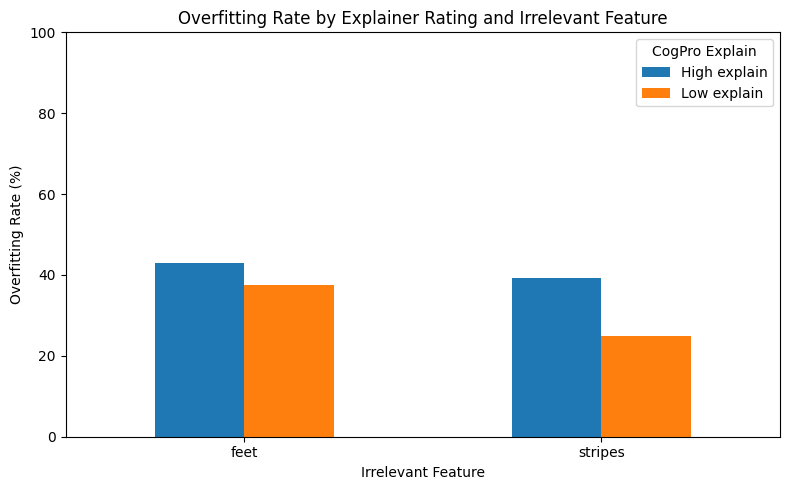

In [63]:
# High/low explainer rating
df_params['explain_group'] = np.where(
    df_params['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

# Overfitting rate by explain group and irrelevant feature
overfit_explain_summary = (
    df_params
    .groupby(['explain_group', 'irrelevant_dim'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_explain_summary['overfit_percent'] = overfit_explain_summary['mean'] * 100

print(overfit_explain_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_explain_summary.pivot(
    index='irrelevant_dim',
    columns='explain_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Explainer Rating and Irrelevant Feature')
ax.set_xlabel('Irrelevant Feature')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Explain')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProExplainanddim.png'), dpi=300)
plt.show()

  explain_group         task      mean  sum  count  overfit_percent
0  High explain      predict  0.333333    4     12        33.333333
1  High explain  accommodate  0.466667    7     15        46.666667
2   Low explain      predict  0.500000    4      8        50.000000
3   Low explain  accommodate  0.400000    2      5        40.000000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_51179/1428687838.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['explain_group', 'task'])['overfit']


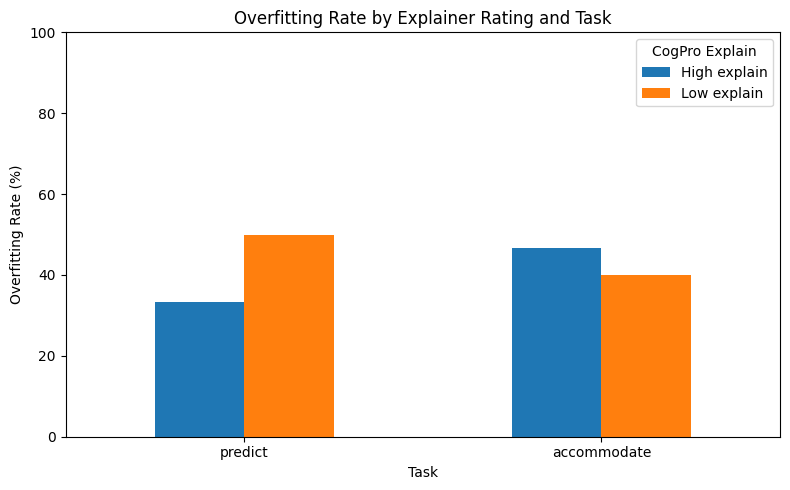

In [39]:
# High/low explainer rating
df_params['explain_group'] = np.where(
    df_params['cogpro_explain'] >= 4,
    'High explain',
    'Low explain'
)

# Overfitting rate by explain group and irrelevant feature
overfit_explain_summary = (
    df_params
    .groupby(['explain_group', 'task'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_explain_summary['overfit_percent'] = overfit_explain_summary['mean'] * 100

print(overfit_explain_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_explain_summary.pivot(
    index='task',
    columns='explain_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Explainer Rating and Task')
ax.set_xlabel('Task')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Explain')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProExplainandtask.png'), dpi=300)
plt.show()

  predict_group         task      mean  sum  count  overfit_percent
0  High predict      predict  0.444444    8     18        44.444444
1  High predict  accommodate  0.533333    8     15        53.333333
2   Low predict      predict  0.000000    0      2         0.000000
3   Low predict  accommodate  0.000000    0      2         0.000000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_51179/2237765179.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['predict_group', 'task'])['overfit']


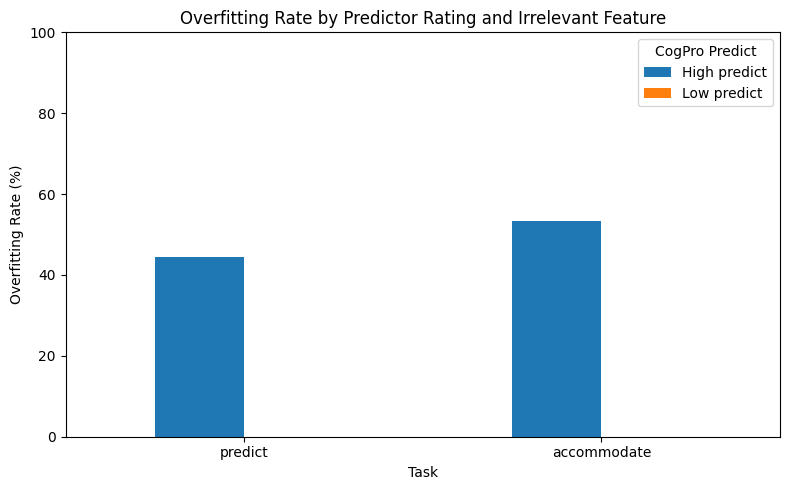

In [14]:
# High/low explainer rating
df_params['predict_group'] = np.where(
    df_params['cogpro_predict'] >= 4,
    'High predict',
    'Low predict'
)

# Overfitting rate by explain group and irrelevant feature
overfit_predict_summary = (
    df_params
    .groupby(['predict_group', 'task'])['overfit']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
)

overfit_predict_summary['overfit_percent'] = overfit_predict_summary['mean'] * 100

print(overfit_predict_summary)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = overfit_predict_summary.pivot(
    index='task',
    columns='predict_group',
    values='overfit_percent'
)

plot_data.plot(kind='bar', ax=ax)

ax.set_title('Overfitting Rate by Predictor Rating and Irrelevant Feature')
ax.set_xlabel('Task')
ax.set_ylabel('Overfitting Rate (%)')
ax.set_ylim(0, 100)
ax.legend(title='CogPro Predict')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'OverfittingRateByCogProPredictandtask.png'), dpi=300)
plt.show()

Part 2: Testing distribution of all model parameter scores by task

model_param_score         task irrelevant_dim    0     1     2
0                  accommodate           feet  3.0   3.0  15.0
1                  accommodate        stripes  0.0   7.0  15.0
2                      predict           feet  3.0   5.0  13.0
3                      predict        stripes  0.0  11.0   9.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/3367612162.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/3367612162.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


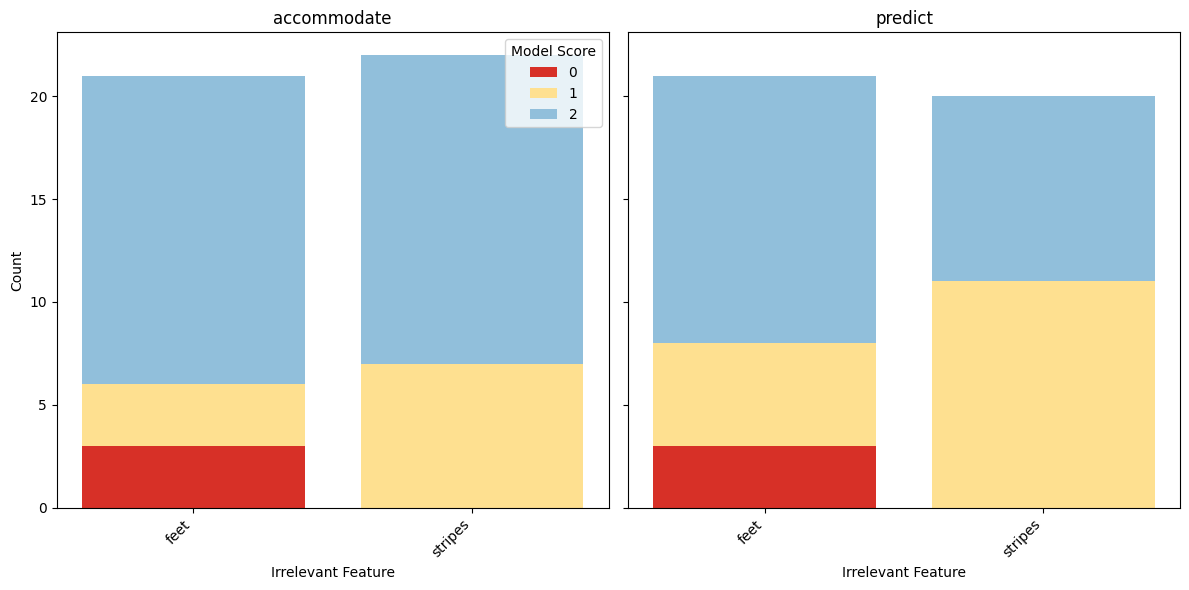

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

model_param_score   0   1   2
task                         
predict             7  20  14
accommodate        10  14  18
Chi-square = 2.076
df = 2
p-value = 0.3541


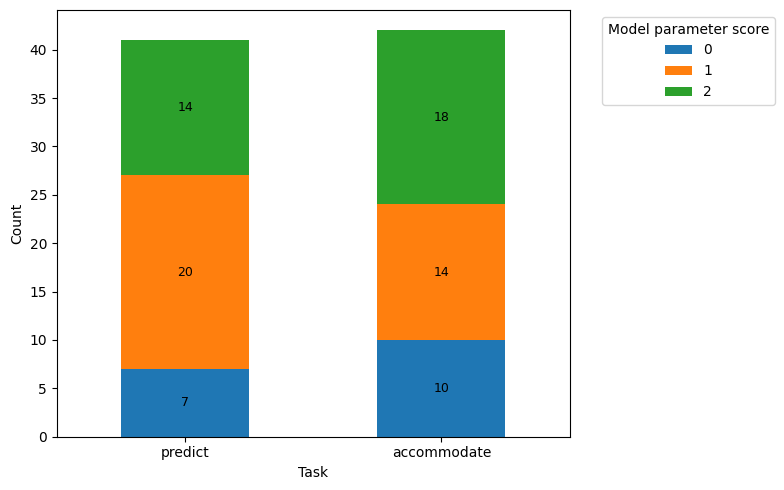

In [65]:
contingency_all = pd.crosstab(
    df_params['task'],
    df_params['model_param_score']
)

print(contingency_all)

chi2, p, dof, expected = chi2_contingency(contingency_all)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

ax = contingency_all.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("Task")
ax.set_ylabel("Count")
#ax.set_title("Model Parameter Scores by Task")

# Add numerical labels with the count
for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fontsize=9
    )
plt.legend(title="Model parameter score", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(
    os.path.join(outputdir, "Figure2_TaskByModelParamScore_StackedBars.png"),
    dpi=300
)
plt.show()
plt.close()

#Function of condition, wing relevance, and wing direction - the full distribution across that 
#code explanations later


**Primary Analysis #2: Predicting Feature Importance Ratings**

In [20]:
#Create map from short codes to feature descriptions

feet_map = {
    'webbed': 'f',
    'curved/pointy': 'c'
}

stripes_map = {
    'up/right': 'e',
    'up/left': 'w'
}



feature_maps = {
    'feet': feet_map,
    'stripes': stripes_map
}


In [21]:
#Compute feature importance scores

from doctest import debug


def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'stripes']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)
#df_filtered = compute_feature_importance_from_df(df_filtered)
if debug:
    print(df_combined['feet_importance'])

response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'webbed' internal: 'f' high: 'c' low: 'f'
in negative
response: 'webbed' internal: 'f' high: 'f' low: 'c'
response: 'curved/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curved/pointy' internal: 'c' high: 'c' low: 'f'
response: 'webbed' internal: 'f' high: 'c' low:

In [22]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'stripes_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','stripes_high', 'feet_discrete_slider.response',
    'cogpro_explain', 'cogpro_predict'
]

df_long = df_combined[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'stripes_high', 'feet_high', 'feet_discrete_slider.response', 'cogpro_explain', 'cogpro_predict'],
    value_vars=['feet_importance', 'stripes_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

print(df_long.tail(20))

     participant     task relevant_dim irrelevant_dim stripes_high feet_high  \
148           65  predict         feet        stripes            E         F   
149           66  predict      stripes           feet            E         F   
150           67  predict      stripes           feet            E         F   
151           68  predict         feet        stripes            W         F   
152           69  predict         feet        stripes            W         C   
153           70  predict      stripes           feet            E         C   
154           71  predict      stripes           feet            W         C   
155           72  predict         feet        stripes            W         F   
156           73  predict      stripes           feet            W         C   
157           74  predict      stripes           feet            E         C   
158           75  predict      stripes           feet            W         C   
159           76  predict         feet  

FEET — relevant: 42 points
FEET — irrelevant: 42 points
STRIPES — relevant: 42 points
STRIPES — irrelevant: 42 points


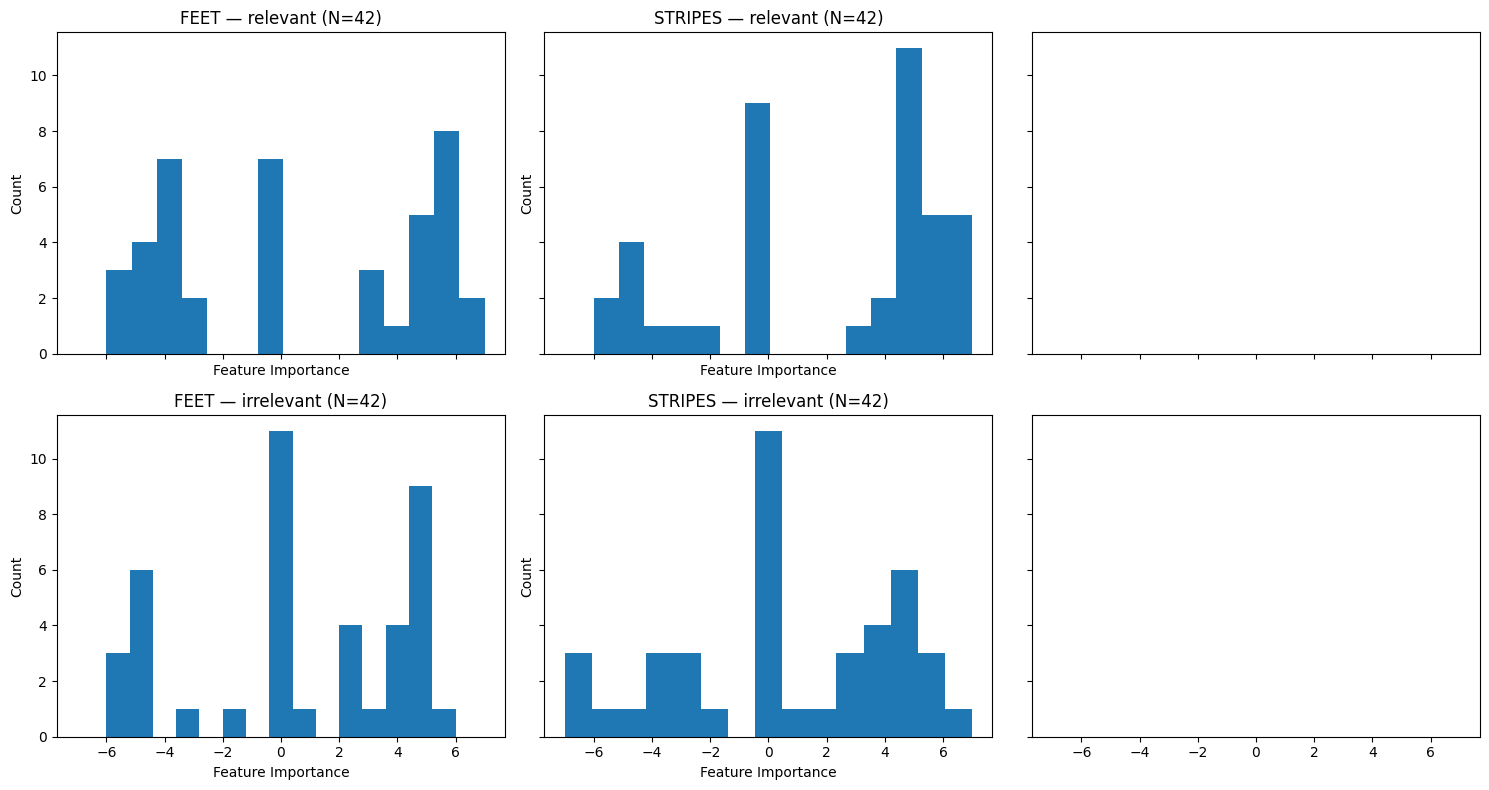

In [23]:
import matplotlib.pyplot as plt

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):
        
        ax = axes[row, col]
        
        subset = df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ]
        
        # Number of rows in this subset
        n_points = len(subset)
        print(f"{feat.upper()} — {rel}: {n_points} points")
        
        ax.hist(subset['feature_importance'], bins=15, density=False)
        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeature.png'))
plt.show()


/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


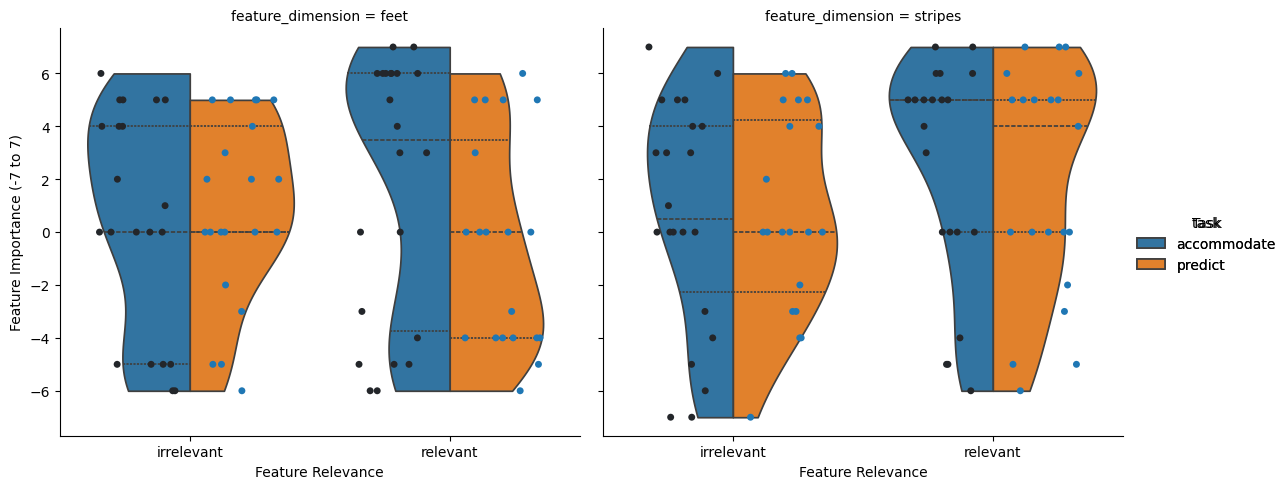

In [24]:
g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    col='feature_dimension',
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    #density_norm='width',   
    #common_norm=False,     
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.stripplot,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=True,
    alpha=1,
    size=5,
    jitter=0.3,
    legend=False
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure4_FeatureImportance_ByTask_Relevance_FacetedByDimension_WithPoints.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/2558768501.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/2558768501.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


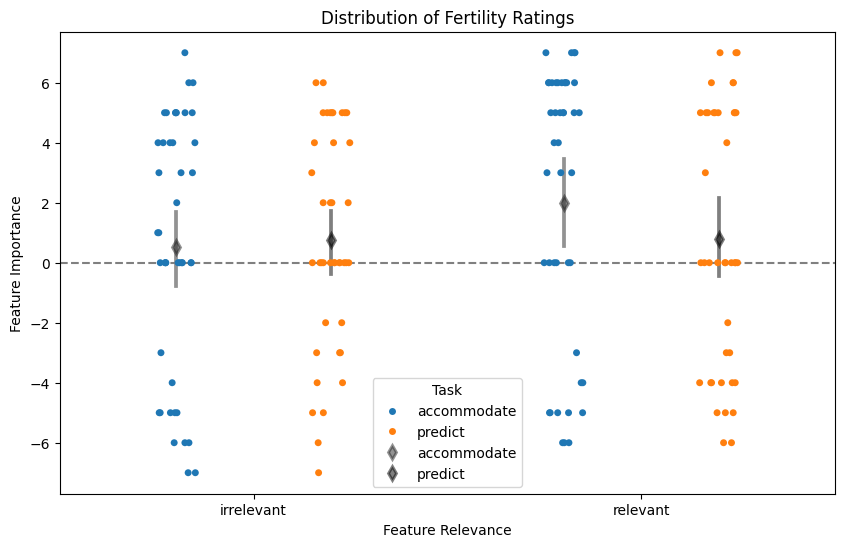

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.stripplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/197174763.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/197174763.py:12: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


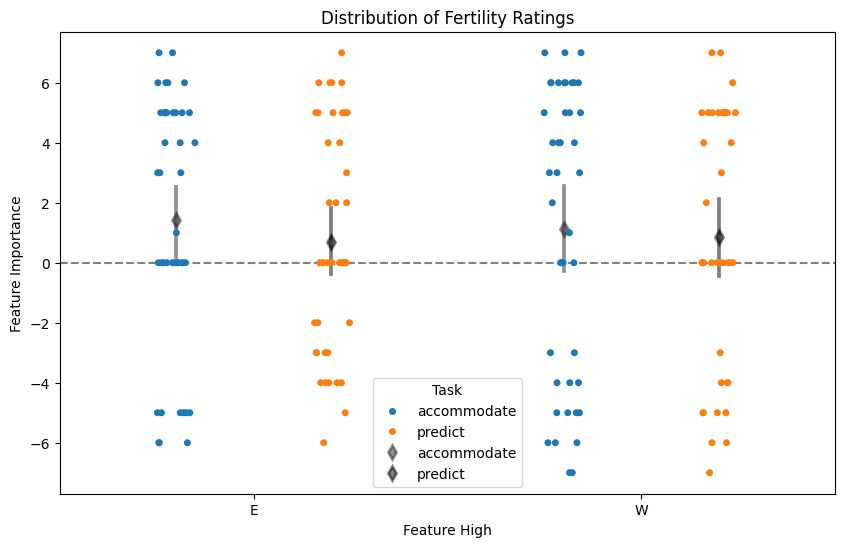

In [29]:

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df_long,
    x='stripes_high',
    y='feature_importance',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_long,
    x='stripes_high',
    y='feature_importance',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Ratings')
plt.ylabel('Feature Importance')
plt.xlabel('Feature High')
plt.legend(title='Task')
#plt.savefig(os.path.join(outputdir, 'FeatureImportanceByTaskAndFeetViolin.png'), dpi=300)

plt.show()


In [57]:
print(df_long)

     participant         task relevant_dim irrelevant_dim stripes_high  \
0              1  accommodate      stripes           feet            E   
1              2  accommodate         feet        stripes            W   
2              3  accommodate      stripes           feet            W   
3              4  accommodate      stripes           feet            W   
4              5  accommodate         feet        stripes            W   
..           ...          ...          ...            ...          ...   
163           80      predict         feet        stripes            E   
164           81      predict      stripes           feet            W   
165           82      predict         feet        stripes            W   
166           83      predict      stripes           feet            E   
167           84      predict      stripes           feet            W   

    feet_high feet_discrete_slider.response  cogpro_explain  cogpro_predict  \
0           C                   

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/2337344439.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/2337344439.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/2337344439.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/2337344439.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


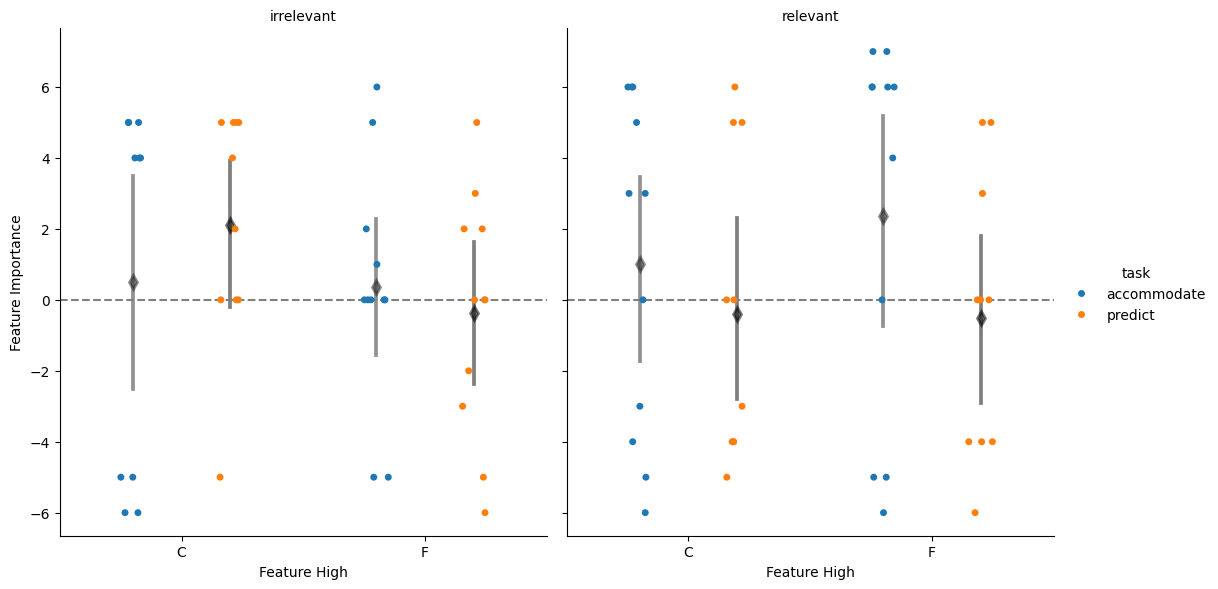

In [58]:
df_feet = df_long[df_long['feature_dimension'] == 'feet']

g = sns.catplot(
    data=df_feet,
    x='feet_high',
    y='feature_importance',
    hue='task',
    col='feature_relevance',
    kind='strip',
    dodge=True,
    jitter=.1,
    height=6,
    aspect=0.9
)

for ax, relevance in zip(g.axes.flat, df_long['feature_relevance'].unique()):
    
    sns.pointplot(
        data=df_feet[df_feet['feature_relevance'] == relevance],
        x='feet_high',
        y='feature_importance',
        hue='task',
        dodge=0.4,
        join=False,
        markers='d',
        errorbar=('ci', 95),
        color='black',
        alpha=.5,
        ax=ax,
        legend=False
    )

    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels("Feature High", "Feature Importance")
g.set_titles("{col_name}")

plt.show()

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/818873672.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/818873672.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/818873672.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_55000/818873672.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


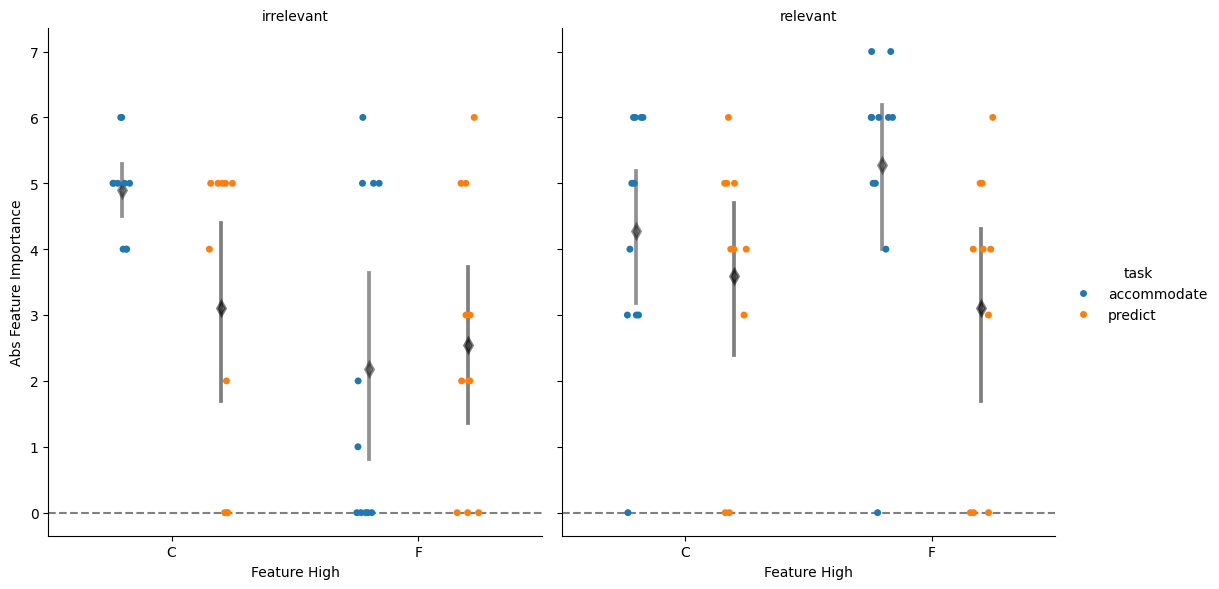

In [62]:
g = sns.catplot(
    data=df_feet,
    x='feet_high',
    y='abs_feature_importance',
    hue='task',
    col='feature_relevance',
    kind='strip',
    dodge=True,
    jitter=.1,
    height=6,
    aspect=0.9
)

for ax, relevance in zip(g.axes.flat, df_feet['feature_relevance'].unique()):
    
    sns.pointplot(
        data=df_feet[df_feet['feature_relevance'] == relevance],
        x='feet_high',
        y='abs_feature_importance',
        hue='task',
        dodge=0.4,
        join=False,
        markers='d',
        errorbar=('ci', 95),
        color='black',
        alpha=.5,
        ax=ax,
        legend=False
    )

    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels("Feature High", "Abs Feature Importance")
g.set_titles("{col_name}")

plt.show()

In [61]:
(
    df_feet[df_feet['feature_relevance'] == 'relevant']
    .groupby('task')['feature_importance']
    .agg(['mean', 'count'])
)

,mean,count
task,,
accommodate,1.681818,22
predict,-0.450000,20


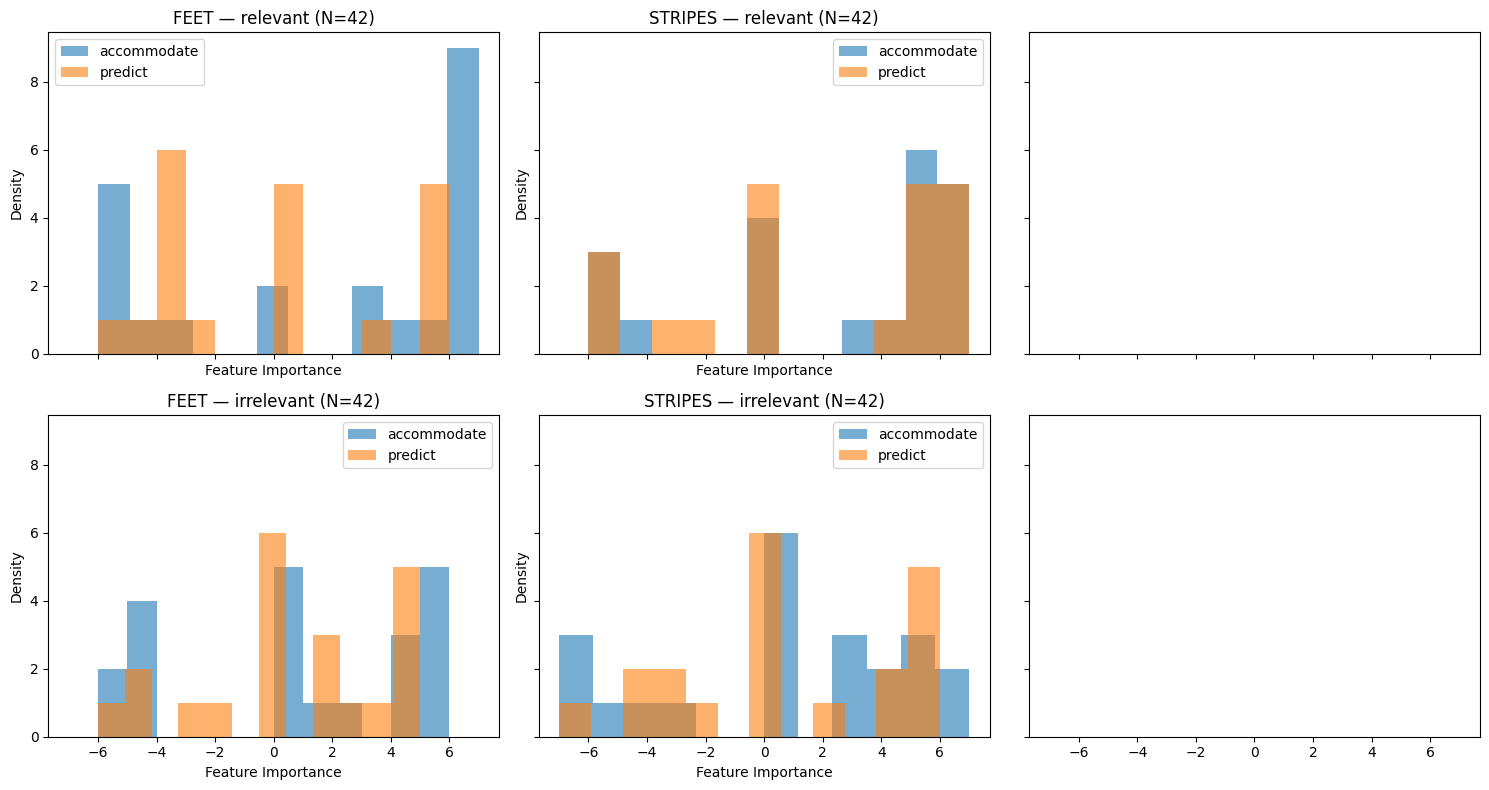

In [30]:
import matplotlib.pyplot as plt

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Feature Importance")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'FeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

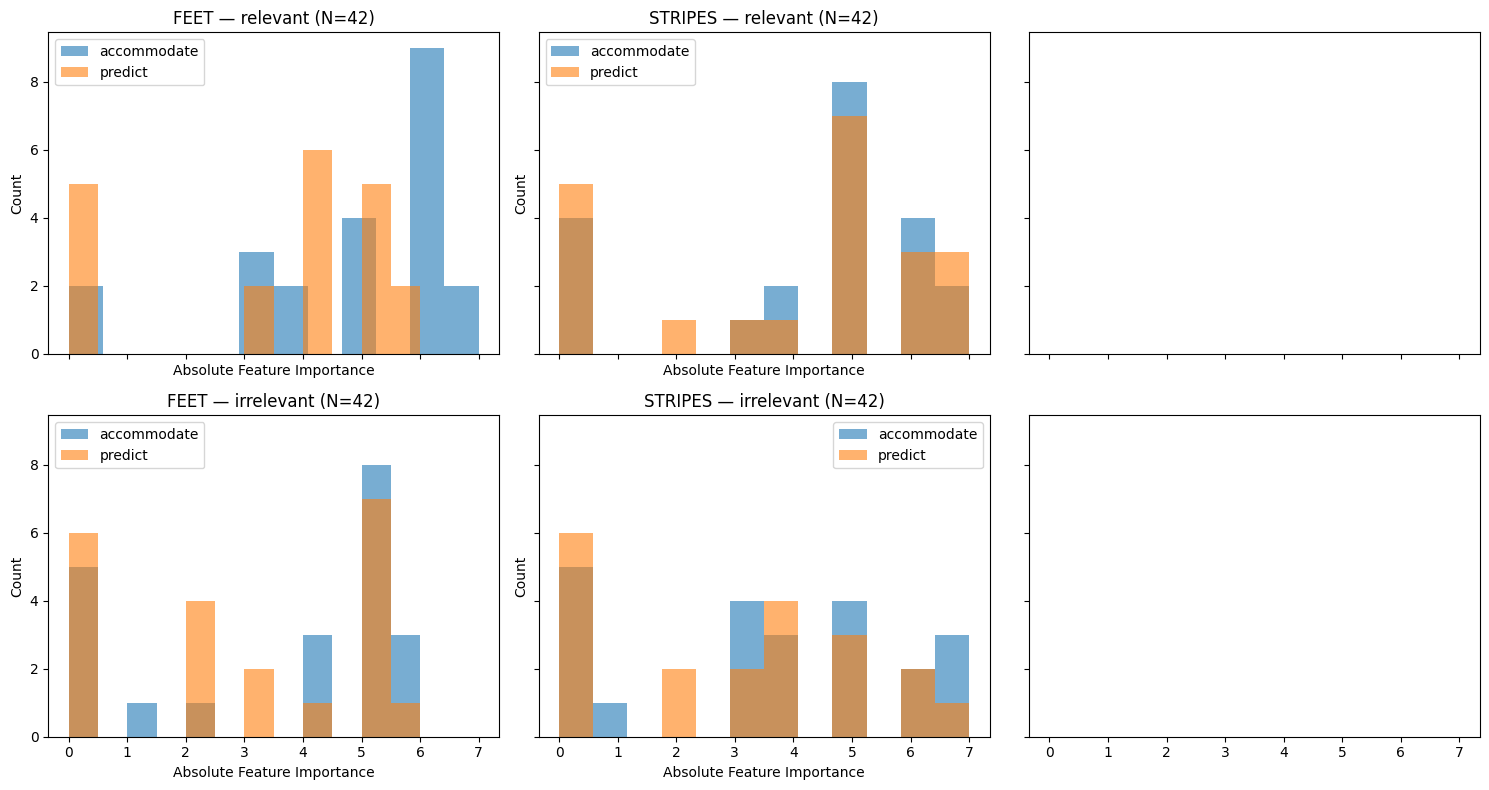

In [31]:
df_long['abs_feature_importance'] = df_long['feature_importance'].abs()
import matplotlib.pyplot as plt
import os

features = ['feet', 'stripes']
relevance_states = ['relevant', 'irrelevant']
tasks = df_long['task'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for col, feat in enumerate(features):
    for row, rel in enumerate(relevance_states):

        ax = axes[row, col]

        for task in tasks:
            subset = df_long[
                (df_long['feature_dimension'] == feat) &
                (df_long['feature_relevance'] == rel) &
                (df_long['task'] == task)
            ]

            ax.hist(
                subset['abs_feature_importance'],
                bins=12,
                density=False,
                alpha=0.6,
                label=task
            )

        n_points = len(df_long[
            (df_long['feature_dimension'] == feat) &
            (df_long['feature_relevance'] == rel)
        ])

        ax.set_title(f"{feat.upper()} — {rel} (N={n_points})")
        ax.set_xlabel("Absolute Feature Importance")
        ax.set_ylabel("Count")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'AbsoluteFeatureImportanceScoresbyFeaturesAndTask.png'))
plt.show()

/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/predictproj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#1f77b4'` for the same effect.

  func(*plot_args, **plot_kwargs)


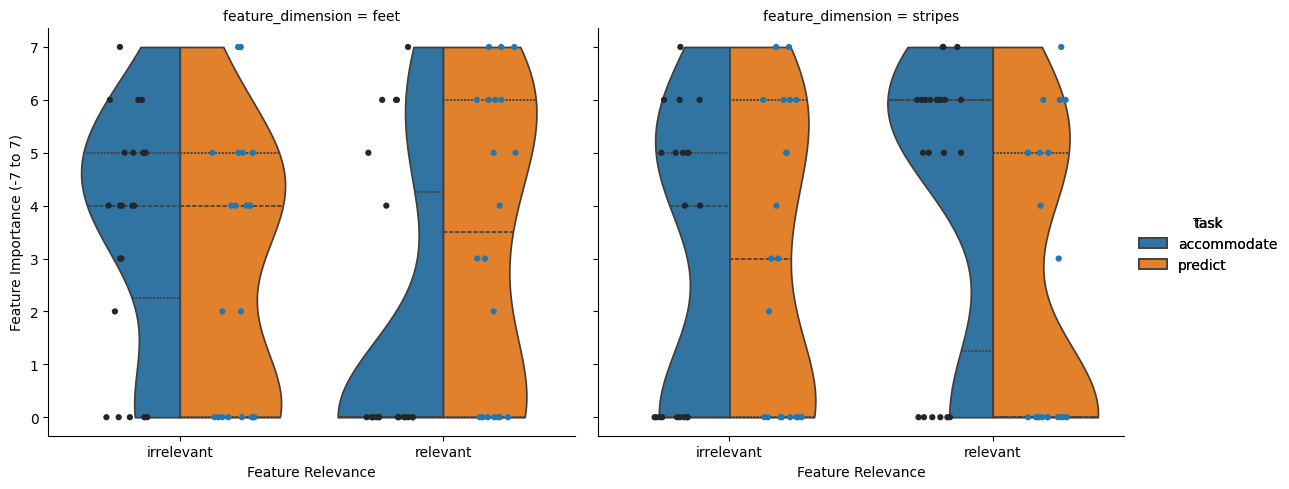

In [75]:
g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='abs_feature_importance',
    hue='task',
    col='feature_dimension',
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    #density_norm='width',   
    #common_norm=False,     
    height=5,
    aspect=1
)

g.map_dataframe(
    sns.stripplot,
    x='feature_relevance',
    y='abs_feature_importance',
    hue='task',
    dodge=True,
    alpha=1,
    size=4.5,
    jitter=0.18,
    legend=False
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

plt.show()

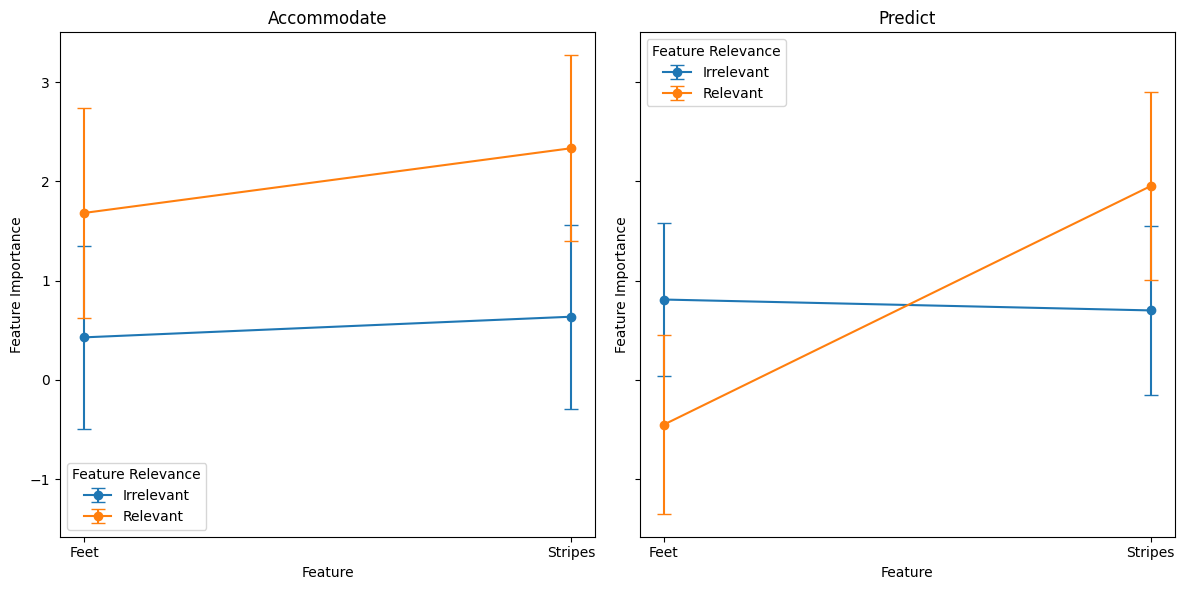

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'stripes']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, task in enumerate(df_long["task"].unique()):
    ax = axes[i]
    
    task_df = df_long[df_long["task"] == task]

    for rel in ['irrelevant', 'relevant']:
        rel_df = task_df[task_df["feature_relevance"] == rel]
        
        means = []
        ses = []

        for feat in features:
            cell = rel_df[rel_df["feature_dimension"] == feat]["feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

        label = rel.capitalize()
        ax.errorbar(
            range(len(features)),
            means,
            yerr=ses,
            marker='o',
            capsize=5,
            label=label
        )

    ax.set_title(task.capitalize())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([f.capitalize() for f in features])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Feature Importance")
    ax.legend(title="Feature Relevance")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure5FeatureImportanceByTaskAndRelevance.png'))
plt.show()

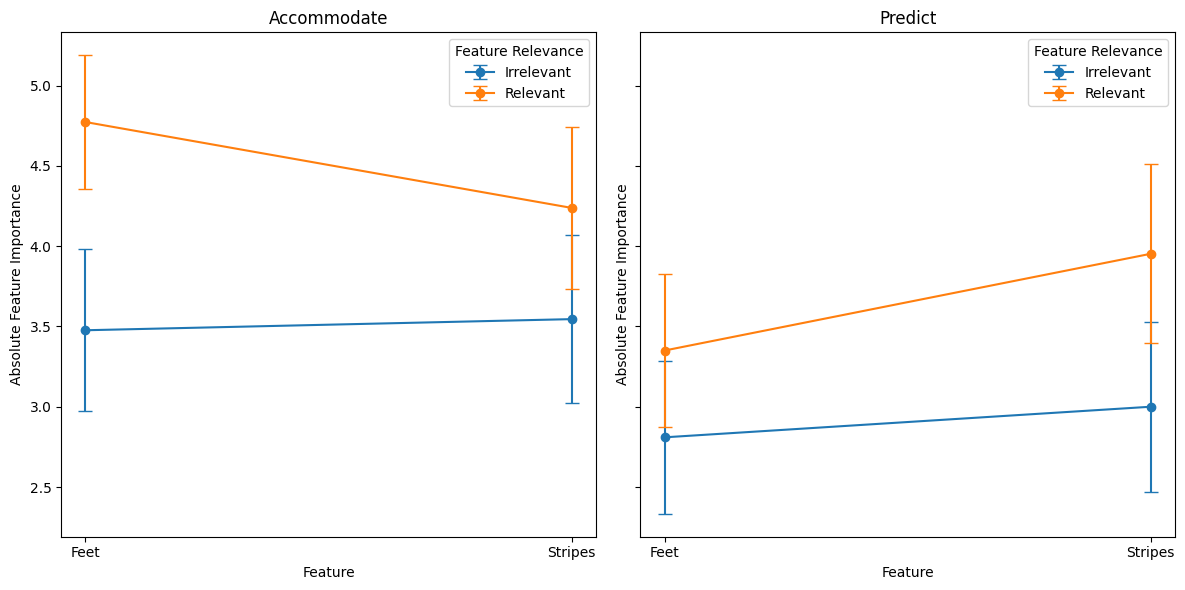

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import os

features = ['feet', 'stripes']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, task in enumerate(df_long["task"].unique()):
    ax = axes[i]
    
    task_df = df_long[df_long["task"] == task]

    for rel in ['irrelevant', 'relevant']:
        rel_df = task_df[task_df["feature_relevance"] == rel]
        
        means = []
        ses = []

        for feat in features:
            cell = rel_df[rel_df["feature_dimension"] == feat]["abs_feature_importance"]
            
            means.append(cell.mean())
            ses.append(cell.std(ddof=1) / np.sqrt(len(cell)) if len(cell) > 1 else 0)

        label = rel.capitalize()
        ax.errorbar(
            range(len(features)),
            means,
            yerr=ses,
            marker='o',
            capsize=5,
            label=label
        )

    ax.set_title(task.capitalize())
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([f.capitalize() for f in features])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Absolute Feature Importance")
    ax.legend(title="Feature Relevance")

plt.tight_layout()
plt.show()

In [34]:
print(df_long)
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_for_R-Study5Pilot3.csv'), index=False)

     participant         task relevant_dim irrelevant_dim stripes_high  \
0              1  accommodate      stripes           feet            E   
1              2  accommodate         feet        stripes            W   
2              3  accommodate      stripes           feet            W   
3              4  accommodate      stripes           feet            W   
4              5  accommodate         feet        stripes            W   
..           ...          ...          ...            ...          ...   
163           80      predict         feet        stripes            E   
164           81      predict      stripes           feet            W   
165           82      predict         feet        stripes            W   
166           83      predict      stripes           feet            E   
167           84      predict      stripes           feet            W   

    feet_high feet_discrete_slider.response  cogpro_explain  cogpro_predict  \
0           C                   

In [35]:
means = (
    df_long
    .groupby(["task", "feature_relevance", "feature_dimension"])["feature_importance"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(means)


          task feature_relevance feature_dimension      mean       std  count
0  accommodate        irrelevant              feet  0.428571  4.225771     21
1  accommodate        irrelevant           stripes  0.636364  4.337494     22
2  accommodate          relevant              feet  1.681818  4.970258     22
3  accommodate          relevant           stripes  2.333333  4.293406     21
4      predict        irrelevant              feet  0.809524  3.515950     21
5      predict        irrelevant           stripes  0.700000  3.812721     20
6      predict          relevant              feet -0.450000  4.019361     20
7      predict          relevant           stripes  1.952381  4.352886     21


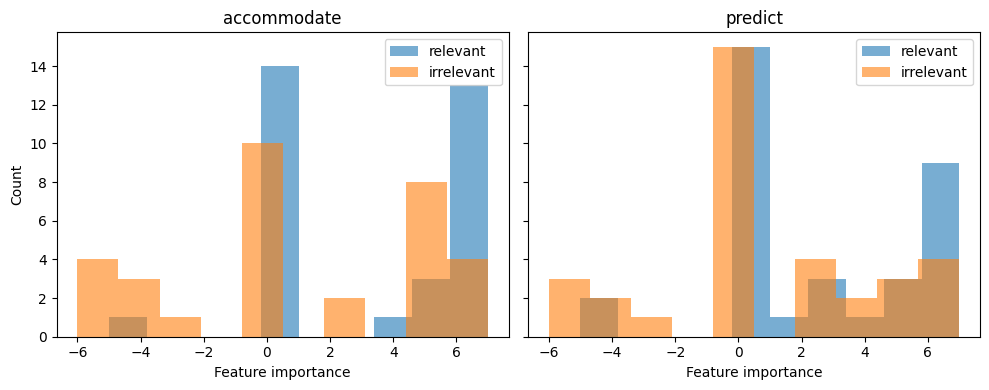

In [40]:
tasks = df_long['task'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(tasks),
    figsize=(5 * len(tasks), 4),
    sharey=True
)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    for label in ['relevant', 'irrelevant']:
        values = df_long.loc[
            (df_long['task'] == task) &
            (df_long['feature_relevance'] == label),
            'feature_importance'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=label)

    ax.set_title(task)
    ax.set_xlabel("Feature importance")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3_FeatureImportanceByTaskAndRelevance.png'), dpi=300)
plt.show()


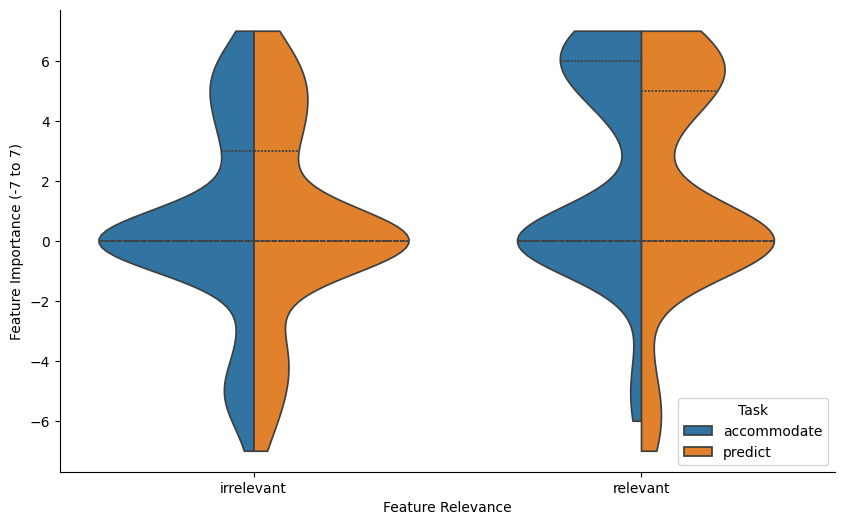

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc='lower right')
plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


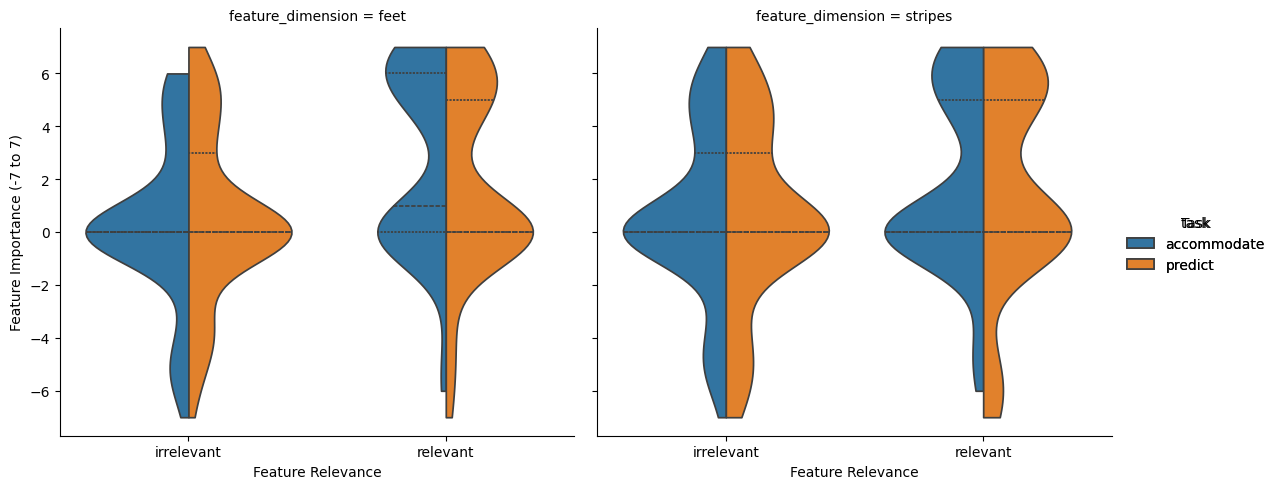

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

df_long['feature_relevance'] = pd.Categorical(
    df_long['feature_relevance'],
    categories=['irrelevant', 'relevant'],
    ordered=False
)

g = sns.catplot(
    data=df_long,
    x='feature_relevance',
    y='feature_importance',
    hue='task',
    col='feature_dimension',     
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    height=5,
    aspect=1
)

g.set_axis_labels('Feature Relevance', 'Feature Importance (-7 to 7)')
g.add_legend(title='Task')

sns.despine()

plt.savefig(
    os.path.join(outputdir, 'Figure4_FeatureImportance_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300
)

plt.show()

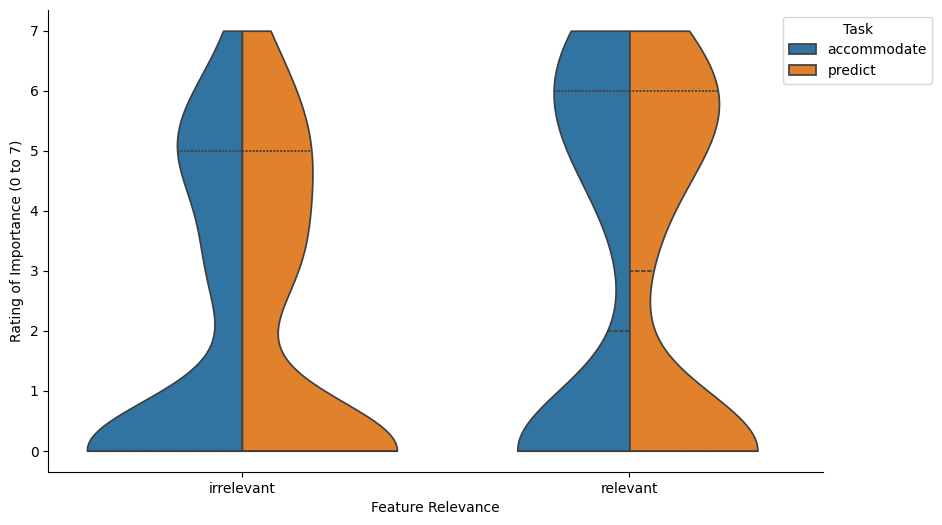

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['irrelevant', 'relevant'], ordered=False)
# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='abs_feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

sns.despine()
#plt.axhline(0, color='gray', linestyle='--')  # line at 0
#plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Rating of Importance (0 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task', loc ='upper right', bbox_to_anchor=(1.15, 1))
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()


**Analysis 3: Predicting Fertility Ratings**

In [36]:
#Group by average food amount per item in training
df = df_combined[['task', 'training_image_order', 'fertility_score', 'conditionOrder']]
df_long2 = (
    df
    .explode(['training_image_order', 'fertility_score'])
    .rename(columns={'training_image_order': 'item'})
)
avg_food = (
    df_long2
    .groupby(['task', 'conditionOrder', 'item'], as_index=False)
    ['fertility_score']
    .mean()
)
avg_food_train = avg_food.copy()
print(avg_food_train.head(20))


           task  conditionOrder item fertility_score
0   accommodate               1  E_C             6.5
1   accommodate               1  E_F             7.5
2   accommodate               1  W_C             6.5
3   accommodate               1  W_F             2.0
4   accommodate               2  E_C             4.0
5   accommodate               2  E_F             4.0
6   accommodate               2  W_C             6.5
7   accommodate               2  W_F             9.0
8   accommodate               3  E_C             5.0
9   accommodate               3  E_F             7.5
10  accommodate               3  W_C             3.0
11  accommodate               3  W_F             6.0
12  accommodate               4  E_C             6.0
13  accommodate               4  E_F             6.5
14  accommodate               4  W_C             3.0
15  accommodate               4  W_F             4.0
16  accommodate               5  E_C             8.0
17  accommodate               5  E_F          

In [37]:
#Get food consumption ratings by item

df = df_combined[['task', 'conditionOrder', 'testing_image_order', 'testing_responses',
                  'relevant_dim', 'irrelevant_dim', 'stripes_high', 'feet_high']]
df_long2 = (
    df
    .explode(['testing_image_order', 'testing_responses'])
    .rename(columns={'testing_image_order': 'item'})
)
avg_food_test = df_long2.copy()
print(avg_food_test)


           task  conditionOrder item testing_responses relevant_dim  \
0   accommodate              20  E_F               5.0      stripes   
0   accommodate              20  W_F               2.0      stripes   
0   accommodate              20  E_C               9.0      stripes   
0   accommodate              20  W_C               6.0      stripes   
1   accommodate              19  W_C               4.0         feet   
..          ...             ...  ...               ...          ...   
82      predict              12  E_F              10.0      stripes   
83      predict              26  E_F               3.0      stripes   
83      predict              26  W_F               6.0      stripes   
83      predict              26  W_C               7.0      stripes   
83      predict              26  E_C               9.0      stripes   

   irrelevant_dim stripes_high feet_high  
0            feet            E         C  
0            feet            E         C  
0            feet 

In [38]:
#Now merge the two (actual food amounts in training vs ratings in testing) and compute error
df_merged = avg_food_test.merge(
    avg_food_train,
    on=['task', 'conditionOrder', 'item'],
    how='left'
)

#Add Error and absolute error
df_merged['error'] = (
    df_merged['testing_responses'] - df_merged['fertility_score']
)
df_merged['abs_error'] = df_merged['error'].abs()
df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print(df_merged)

            task  conditionOrder item testing_responses relevant_dim  \
0    accommodate              20  E_F               5.0      stripes   
1    accommodate              20  W_F               2.0      stripes   
2    accommodate              20  E_C               9.0      stripes   
3    accommodate              20  W_C               6.0      stripes   
4    accommodate              19  W_C               4.0         feet   
..           ...             ...  ...               ...          ...   
331      predict              12  E_F              10.0      stripes   
332      predict              26  E_F               3.0      stripes   
333      predict              26  W_F               6.0      stripes   
334      predict              26  W_C               7.0      stripes   
335      predict              26  E_C               9.0      stripes   

    irrelevant_dim stripes_high feet_high fertility_score error abs_error  \
0             feet            E         C             5.5 

In [39]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['stripes', 'feet']] = df_merged['item'].str.split('_', expand=True)
print("Mean error by stripes:")
print(df_merged.groupby('stripes')['error'].mean())

print("Mean error by feet:")
print(df_merged.groupby('feet')['error'].mean())
#t-test: stripes 1 vs stripes 2 absolute error 
stripes1 = df_merged.loc[df_merged['feet'] == 'C', 'error']
stripes2 = df_merged.loc[df_merged['feet'] == 'F', 'error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(stripes1), pd.to_numeric(stripes2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean error by stripes:
stripes
E    0.306548
W     0.53869
Name: error, dtype: object
Mean error by feet:
feet
C    0.678571
F    0.166667
Name: error, dtype: object
T = 1.740, p = 0.083


F
C


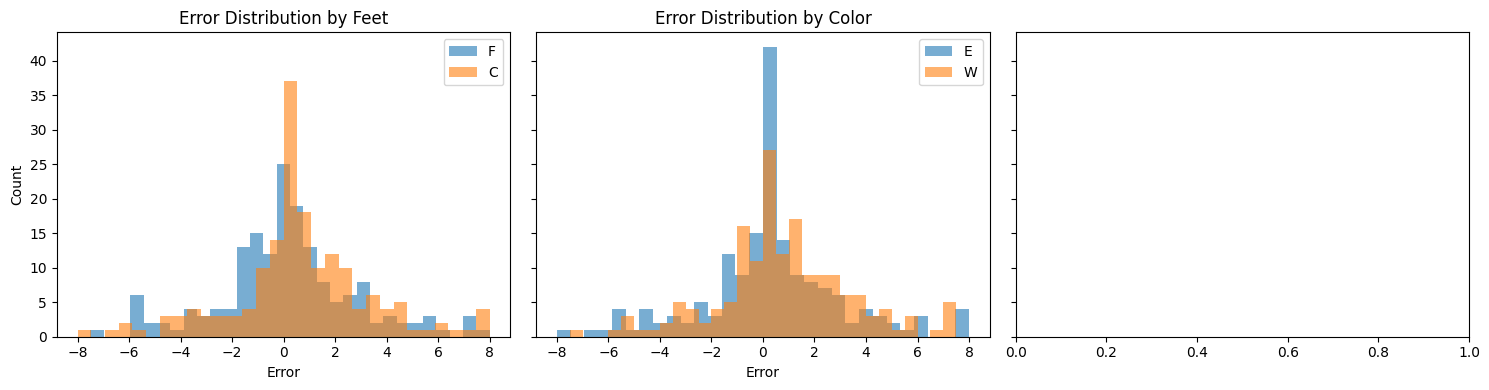

In [40]:
import matplotlib.pyplot as plt

# Make sure error is numeric
df_merged['error'] = pd.to_numeric(df_merged['error'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Tail
for t in df_merged['feet'].unique():
    print(t)
    axes[0].hist(
        df_merged.loc[df_merged['feet'] == t, 'error'],
        bins=30,
        alpha=0.6,
        label=t
    )
axes[0].set_title('Error Distribution by Feet')
axes[0].set_xlabel('Error')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Color ---
for c in df_merged['color'].unique():
    axes[1].hist(
        df_merged.loc[df_merged['color'] == c, 'error'],
        bins=30,
        alpha=0.6,
        label=c
    )
axes[1].set_title('Error Distribution by Color')
axes[1].set_xlabel('Error')
axes[1].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7_ErrorDistributionByFeature.png'), dpi=300)
plt.show()


In [41]:
df_merged.to_csv(os.path.join(outputdirCombined, 'df_merged_for_R_Study5pilot3.csv'), index=False)

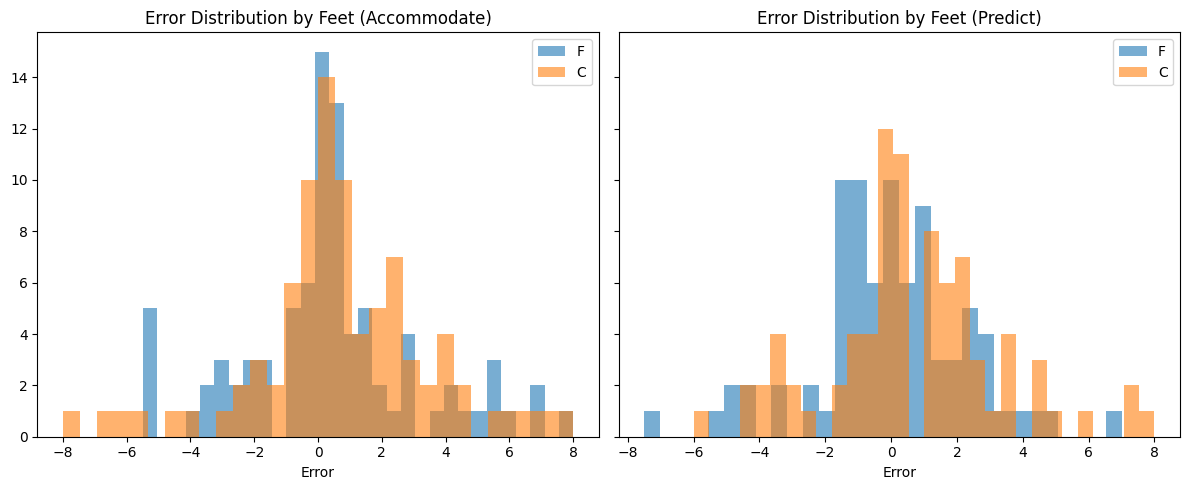

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, task in enumerate(['accommodate', 'predict']):
    for w in df_merged['feet'].unique():
        axes[i].hist(
            df_merged.loc[(df_merged['feet'] == w) & (df_merged['task'] == task), 'error'],
            bins=30,
            alpha=0.6,
            label=w
        )
    axes[i].set_title(f'Error Distribution by Feet ({task.capitalize()})')
    axes[i].set_xlabel('Error')
    axes[i].legend()

plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure7b_ErrorDistributionByFeetAndTask.png'), dpi=300)
plt.show()

In [48]:
#Sanity Check: Mean absolute error by feature (shouldn't be very different)

df_merged[['color', 'feet']] = df_merged['item'].str.split('_', expand=True)

print("Mean abs_error by color:")
print(df_merged.groupby('color')['abs_error'].mean())

print("Mean abs_error by feet:")
print(df_merged.groupby('feet')['abs_error'].mean())
#t-test: color 1 vs color 2 absolute error 
color1 = df_merged.loc[df_merged['feet'] == 'C', 'abs_error']
color2 = df_merged.loc[df_merged['feet'] == 'F', 'abs_error']
t_stat, p_val = stats.ttest_ind(pd.to_numeric(color1), pd.to_numeric(color2), equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")


Mean abs_error by color:
color
E    2.125342
W    1.936817
Name: abs_error, dtype: object
Mean abs_error by feet:
feet
C    2.016735
F    2.045423
Name: abs_error, dtype: object
T = -0.332, p = 0.740


In [43]:
#t-test: predict vs accomodate absolute error
df_merged['error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    2.081395
predict        1.878049
Name: error, dtype: float64
T = 0.991, p = 0.322


In [44]:
#t-test: predict vs accomodate absolute error
df_merged['abs_error'] = pd.to_numeric(df_merged['abs_error'])
print(df_merged.groupby('task')['abs_error'].mean())
errors_task1 = df_merged.loc[df_merged['task'] == 'accommodate', 'abs_error']
errors_task2 = df_merged.loc[df_merged['task'] == 'predict', 'abs_error']
from scipy import stats
t_stat, p_val = stats.ttest_ind(errors_task1, errors_task2, equal_var=False)  # Welch's t-test
print(f"T = {t_stat:.3f}, p = {p_val:.3f}")
summary_df = pd.DataFrame({
    "task": ["accommodate", "predict"],
    "mean_abs_error": [errors_task1.mean(), errors_task2.mean()],
    "t_stat": [t_stat, t_stat], 
    "p_value": [p_val, p_val]    
})

# Save CSV
#summary_df.to_csv(os.path.join(outputdir, "ttest_error.csv"))

task
accommodate    2.081395
predict        1.878049
Name: abs_error, dtype: float64
T = 0.991, p = 0.322


Part 2: Correlations

In [45]:
# Columns indicating whether the item's feature is the "high" dimension (1 or 0 coding)
df_merged['stripes_match_high']  = (df_merged['stripes']  == df_merged['stripes_high']).astype(int)
df_merged['feet_match_high'] = (df_merged['feet'] == df_merged['feet_high']).astype(int)
#print(df_merged.head(20))
# Group by participant
participant_corrs = []

for pid, g in df_merged.groupby(['task', 'conditionOrder']):
    for feat in ['stripes','feet']:
        # Column indicating match to high value
        match_col = f"{feat}_match_high"
        
        # Compute correlation
        corr = g['testing_responses'].corr(g[match_col])
        
        # Determine if this feature is relevant for this participant
        relevant = g['relevant_dim'].iloc[0] == feat
        high_col  = f"{feat}_high"
        
        # Store
        participant_corrs.append({
            'participant': pid,
            'task': g['task'].iloc[0],
            'feature_dimension': feat,
            'high_value': g[high_col].iloc[0],
            'feature_relevance': 'relevant' if relevant else 'irrelevant',
            'correlation': corr,
            'irrelevant_dim': g['irrelevant_dim'].iloc[0],
            'abs_correlation': abs(corr) if pd.notna(corr) else None
        })

df_corr = pd.DataFrame(participant_corrs)
print(df_corr.tail(40))



       participant     task feature_dimension high_value feature_relevance  \
120  (predict, 21)  predict           stripes          W        irrelevant   
121  (predict, 21)  predict              feet          C          relevant   
122  (predict, 22)  predict           stripes          W          relevant   
123  (predict, 22)  predict              feet          C        irrelevant   
124  (predict, 23)  predict           stripes          E        irrelevant   
125  (predict, 23)  predict              feet          F          relevant   
126  (predict, 24)  predict           stripes          E          relevant   
127  (predict, 24)  predict              feet          F        irrelevant   
128  (predict, 25)  predict           stripes          W        irrelevant   
129  (predict, 25)  predict              feet          C          relevant   
130  (predict, 26)  predict           stripes          W          relevant   
131  (predict, 26)  predict              feet          C        

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [46]:
df_corr.to_csv(os.path.join(outputdirCombined, 'df_corr_for_R_Study5Pilot3.csv'), index=False)

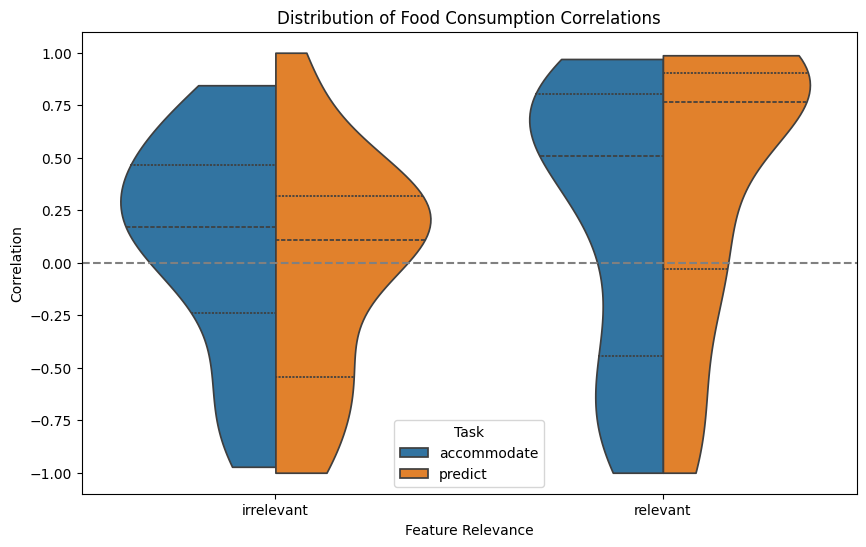

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_corr,
    x='feature_relevance',      # relevant / irrelevant
    y='correlation',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0,

)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Food Consumption Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
#plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolin.png'), dpi=300)

plt.show()


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6671/1081484003.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_6671/1081484003.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


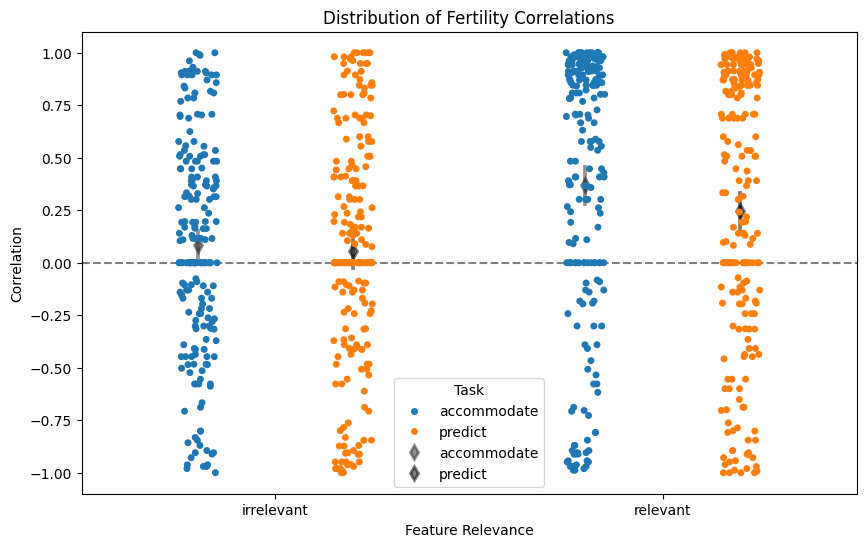

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.stripplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=True,
    jitter=.1,
)

sns.pointplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha = .5
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Fertility Correlations')
plt.ylabel('Correlation')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
plt.savefig(os.path.join(outputdir, 'Figure10_FeatureCorrelationeByTaskAndRelevanceViolinAtt.png'), dpi=300)

plt.show()


/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  func(*plot_args, **plot_kwargs)
/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/seaborn/axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove th

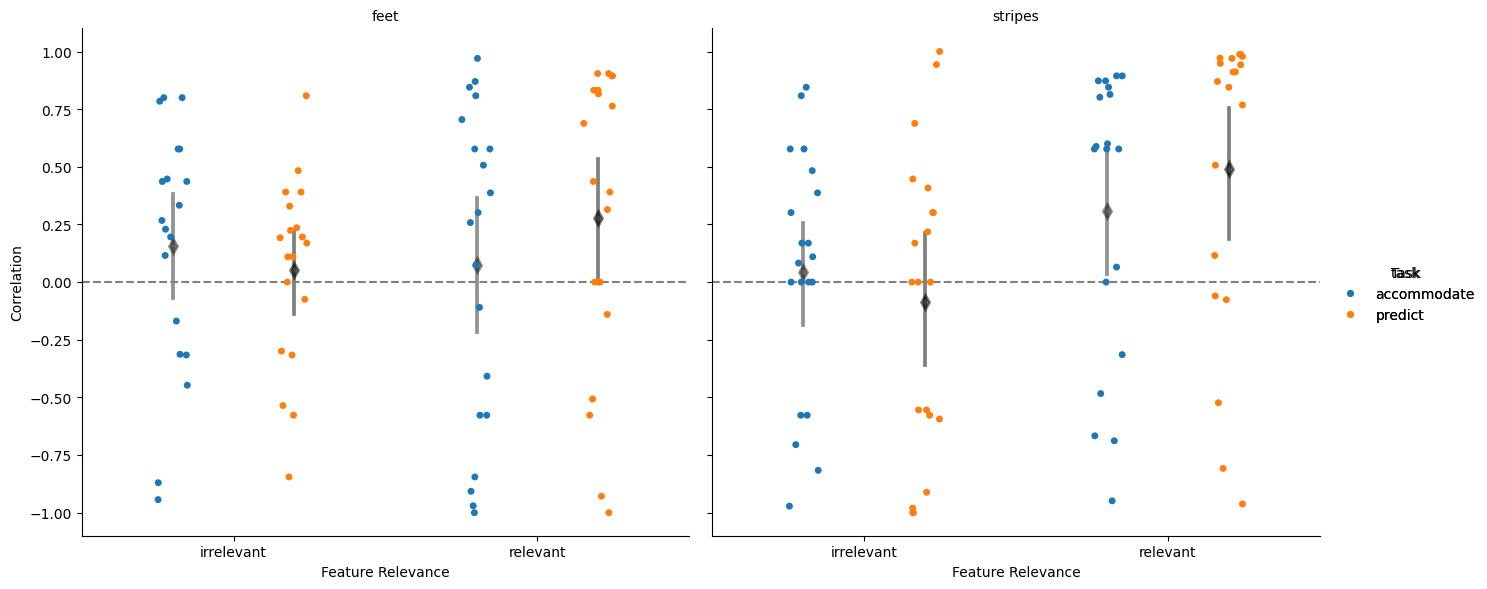

In [48]:
g = sns.catplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    col='feature_dimension',
    col_order=['feet', 'stripes'],   # <-- enforce left/right order
    kind='strip',
    dodge=True,
    jitter=.1,
    height=6,
    aspect=1
)

g.map_dataframe(
    sns.pointplot,
    x='feature_relevance',
    y='correlation',
    hue='task',
    dodge=0.4,
    join=False,
    markers='d',
    errorbar=('ci', 95),
    color='black',
    alpha=.5,
    legend=False
)

for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels('Feature Relevance', 'Correlation')
g.set_titles('{col_name}')
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure10_FeatureCorrelation_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

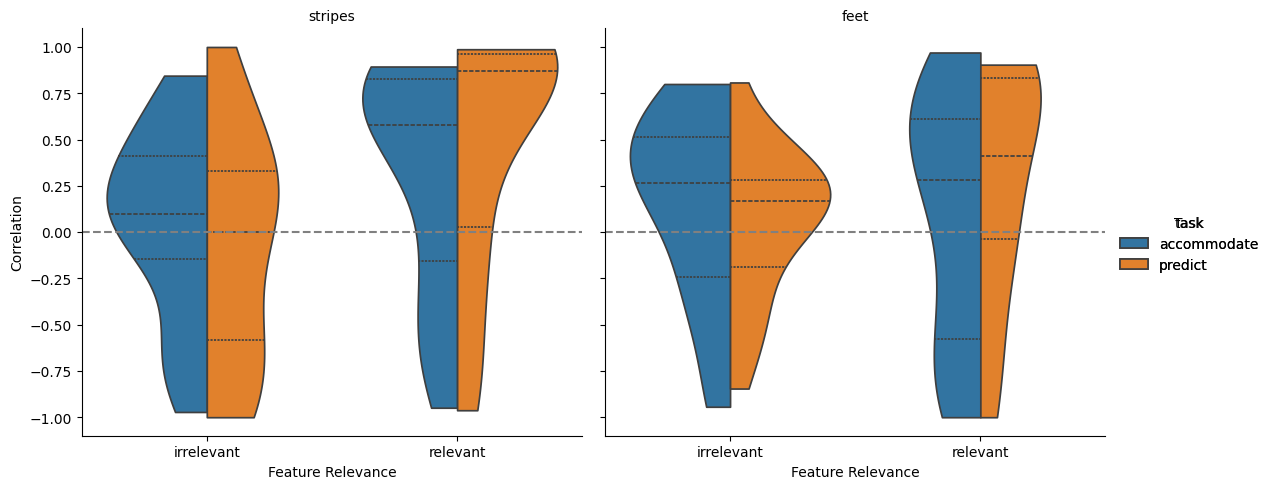

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df_corr,
    x='feature_relevance',
    y='correlation',
    hue='task',
    col='feature_dimension',   # <-- facet here
    kind='violin',
    split=True,
    inner='quartile',
    cut=0,
    height=5,
    aspect=1
)

# Add horizontal line at 0 to each facet
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--')

g.set_axis_labels('Feature Relevance', 'Correlation')
g.set_titles('{col_name}')  # shows feature_dimension in each panel
g.add_legend(title='Task')

plt.savefig(
    os.path.join(outputdir, 'Figure10_FeatureCorrelation_ByTask_Relevance_FacetedByDimension.png'),
    dpi=300
)

plt.show()

In [104]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "correlation ~ task * feature_relevance * feature_dimension",
    df_corr,
    groups=df_corr["participant"]
).fit()

print(model.summary())
model.summary().tables[1].to_csv(
    os.path.join(outputdir, "Figure11_mixedlm_correlationStats.csv")
)

IndexError: index 840 is out of bounds for axis 0 with size 840

In [67]:
avg_corr_task_rel = df_corr.groupby(
    ['task'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)
avg_corr_feature = df_corr.groupby(
    ['feature_dimension'],
    as_index=False
)['correlation'].mean()

print(avg_corr_feature)
avg_corr_relevance = df_corr.groupby(
    ['feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_relevance)

          task  correlation
0  accommodate     0.108902
1      predict     0.084416
  feature_dimension  correlation
0              feet     0.177890
1           stripes     0.015427
  feature_relevance  correlation
0        irrelevant     0.030805
1          relevant     0.162512


In [68]:
print(df_corr.tail(20))

      participant     task feature_dimension high_value feature_relevance  \
60  (predict, 11)  predict           stripes          W        irrelevant   
61  (predict, 11)  predict              feet          F          relevant   
62  (predict, 12)  predict           stripes          E          relevant   
63  (predict, 12)  predict              feet          F        irrelevant   
64  (predict, 13)  predict           stripes          W        irrelevant   
65  (predict, 13)  predict              feet          C          relevant   
66  (predict, 14)  predict           stripes          W          relevant   
67  (predict, 14)  predict              feet          C        irrelevant   
68  (predict, 15)  predict           stripes          W        irrelevant   
69  (predict, 15)  predict              feet          F          relevant   
70  (predict, 16)  predict           stripes          E          relevant   
71  (predict, 16)  predict              feet          F        irrelevant   

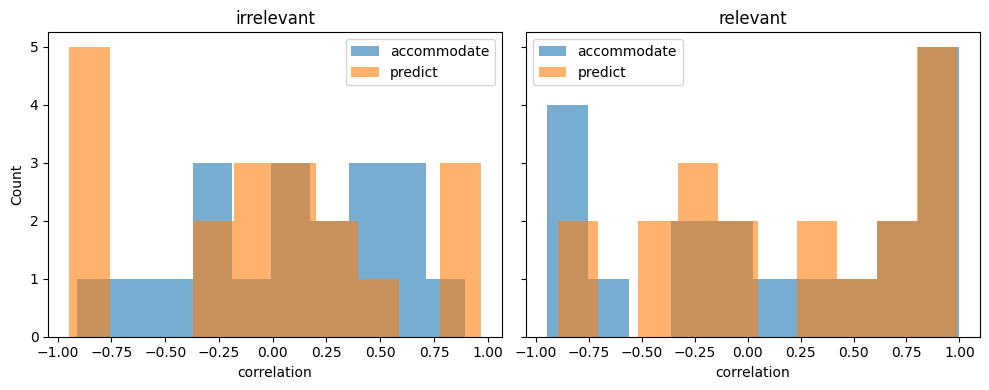

In [69]:
relevance_states = df_corr['feature_relevance'].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(relevance_states),
    figsize=(5 * len(relevance_states), 4),
    sharey=True
)

if len(relevance_states) == 1:
    axes = [axes]

for ax, rel in zip(axes, relevance_states):
    for task in df_corr['task'].unique():
        values = df_corr.loc[
            (df_corr['feature_relevance'] == rel) &
            (df_corr['task'] == task),
            'correlation'
        ]
        ax.hist(values, bins=10, alpha=0.6, label=task)

    ax.set_title(rel)
    ax.set_xlabel("correlation")
    ax.legend()

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(outputdir, 'Figure9_FeatureCorrelationByRelevanceAndTask.png'), dpi=300)
plt.show()

In [50]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  correlation
0  accommodate        irrelevant     0.097537
1  accommodate          relevant     0.188884
2      predict        irrelevant    -0.018050
3      predict          relevant     0.379613


In [71]:
avg_corr_task_rel = df_corr.groupby(
    ['task', 'feature_relevance'],
    as_index=False
)['abs_correlation'].mean()

print(avg_corr_task_rel)


          task feature_relevance  abs_correlation
0  accommodate        irrelevant         0.400888
1  accommodate          relevant         0.634929
2      predict        irrelevant         0.471264
3      predict          relevant         0.568596


In [381]:
import statsmodels.formula.api as smf

model = smf.ols(
    "abs_correlation ~ task * feature_relevance",
    df_corr
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        abs_correlation   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     86.09
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           9.63e-49
Time:                        13:20:09   Log-Likelihood:                -213.85
No. Observations:                 868   AIC:                             435.7
Df Residuals:                     864   BIC:                             454.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [384]:
nan_corrs = df_corr[pd.isna(df_corr['correlation'])]
#print(nan_corrs)
df_corr_clean = df_corr[pd.notna(df_corr['correlation'])].copy()



In [385]:
import statsmodels.formula.api as smf

md = smf.mixedlm(
    "correlation ~ task * feature_relevance",
    df_corr_clean,
    groups=df_corr_clean["participant"],  # random intercept per participant
    re_formula="~feature_relevance"  # random slopes if it converges
)
mdf = md.fit(method='lbfgs')
print(mdf.summary())
#mdf.summary().tables[1].to_csv(os.path.join(outputdir, "mixedlm_correlation.csv"))


                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           correlation
No. Observations:            868               Method:                       REML       
No. Groups:                  434               Scale:                        0.1909     
Min. group size:             2                 Log-Likelihood:               -646.7096  
Max. group size:             2                 Converged:                    Yes        
Mean group size:             2.0                                                        
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      0.177    0.031  5.658 0.000  0.116  0.238
task[T.predict]                               -

Supplementary: Irrelevant Feature Association with food amount and food consumption ratings

Supplementary Models Looking at Feature Dimension

In [412]:
import pandas as pd
from scipy.stats import chi2_contingency

# Loop through rows and determine model parameter score for each participant
participant_rows = []

for _, row in df_filtered.iterrows():
    feet_yes  = 1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0

    model_param_score = feet_yes + color_yes

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],  # predict vs accommodate
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'irrelevant_dim': row['irrelevant_dim'],
        'feet_high': row['feet_high'],
        'overfit': model_param_score == 2  # overfit if both dimensions selected
    })

df_params = pd.DataFrame(participant_rows)

# Compare overfit vs not by condition
contingency = pd.crosstab(
    df_params['task'],
    df_params['overfit']
)

print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

overfit      False  True 
task                     
accommodate    111     93
predict        140     64
Chi-square = 8.117
df = 1
p-value = 0.0044


model_param_score         task irrelevant_dim     0     1     2
0                  accommodate          color  11.0  41.0  43.0
1                  accommodate           feet  10.0  49.0  50.0
2                      predict          color  21.0  49.0  27.0
3                      predict           feet  14.0  56.0  37.0


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['task', 'irrelevant_dim', 'model_param_score'])
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_38149/2493775690.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  score_pivot = score_counts.pivot_table(


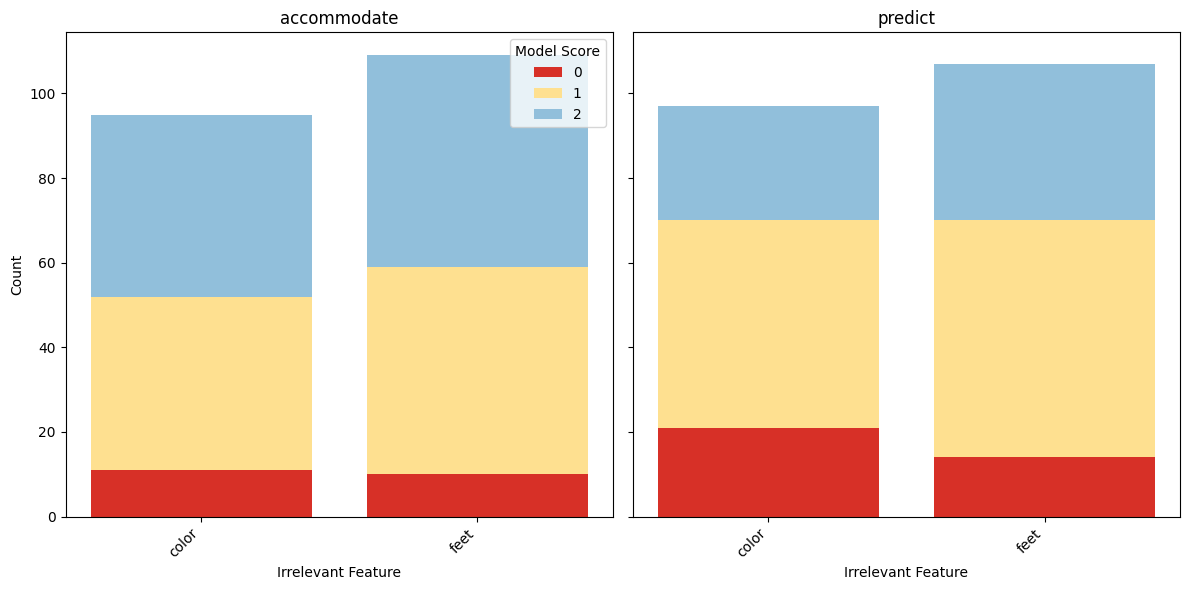

In [413]:
import numpy as np
import matplotlib.pyplot as plt
import os

df_params['task'] = df_params['task'].astype('category')

# Count occurrences of each model_param_score within each task × irrelevant feature
score_counts = (
    df_params
    .groupby(['task', 'irrelevant_dim', 'model_param_score'])
    .size()
    .reset_index(name='count')
)

# Pivot so each score becomes a column
score_pivot = score_counts.pivot_table(
    index=['task', 'irrelevant_dim'],
    columns='model_param_score',
    values='count',
    fill_value=0
).reset_index()

print(score_pivot)

tasks = df_params['task'].cat.categories
buckets = [0, 1, 2]   # now only 3 possible scores with 2 features
colors = ['#d73027', '#fee090', '#91bfdb']  # one color per score

# Create subplots, one per task
fig, axes = plt.subplots(1, len(tasks), figsize=(12, 6), sharey=True)

if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    # Filter for this task
    task_data = score_pivot[score_pivot['task'] == task].copy()

    x = np.arange(len(task_data))
    bottom = np.zeros(len(task_data))

    for i, b in enumerate(buckets):
        values = task_data[b] if b in task_data.columns else np.zeros(len(task_data))
        ax.bar(
            x,
            values,
            bottom=bottom,
            label=f"{b}" if ax == axes[0] else "",
            color=colors[i]
        )
        bottom += values.values if hasattr(values, "values") else values

    ax.set_xticks(x)
    ax.set_xticklabels(task_data['irrelevant_dim'], rotation=45, ha='right')
    ax.set_title(task)
    ax.set_xlabel("Irrelevant Feature")

axes[0].set_ylabel("Count")
axes[0].legend(title="Model Score")
plt.tight_layout()
#plt.savefig(os.path.join(outputdir, 'Figure3ModelParamScoreDistributionByTaskAndIrrelevantFeature.png'))
plt.show()

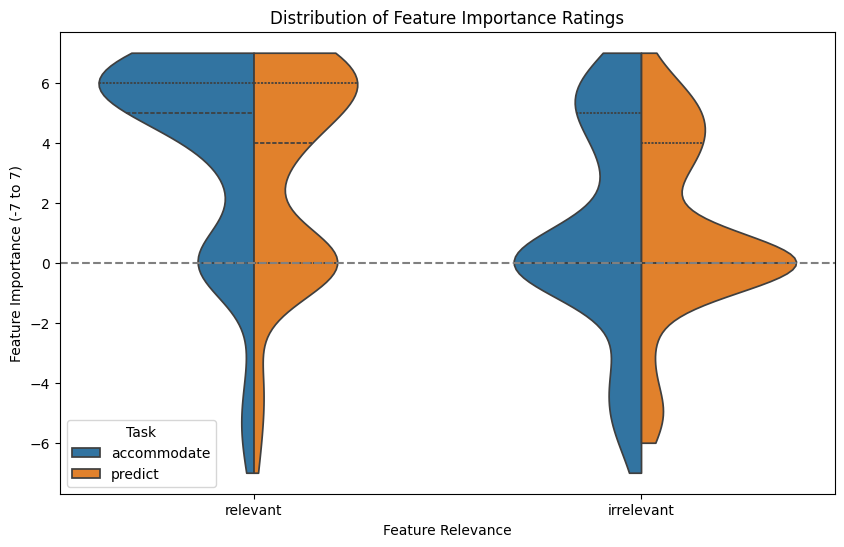

                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         feature_importance
No. Observations:           816             Method:                     REML              
No. Groups:                 408             Scale:                      11.0243           
Min. group size:            2               Log-Likelihood:             -2137.2539        
Max. group size:            2               Converged:                  Yes               
Mean group size:            2.0                                                           
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        3.897    0.232 16.764 0.000  3.441  4.353
task[T.predict]           

/opt/miniconda3/envs/PredictProj/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [416]:
import pandas as pd
"""Reshape to long format with 1 row per participant x feature dimension"""
# Keep only necessary columns
cols_to_keep = [
    'participant', 'task', 
    'feet_importance', 'color_importance',
    'relevant_dim', 'irrelevant_dim', 'feet_high','color_high', 'feet_discrete_slider.response'
]

df_long = df_filtered[cols_to_keep].copy()

# Melt importance columns
df_long = df_long.melt(
    id_vars=['participant', 'task', 'relevant_dim', 'irrelevant_dim', 'color_high', 'feet_high', 'feet_discrete_slider.response'],
    value_vars=['feet_importance', 'color_importance'],
    var_name='feature_dimension',
    value_name='feature_importance'
)

# Simplify feature dimension names
df_long['feature_dimension'] = df_long['feature_dimension'].str.replace('_importance','')

def get_relevance(row):
    if row['feature_dimension'] in [row['relevant_dim']]:
        return 'relevant'
    else:
        return 'irrelevant'

df_long['feature_relevance'] = df_long.apply(get_relevance, axis=1)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot: distribution of ratings by task and relevance
sns.violinplot(
    data=df_long,
    x='feature_relevance',      # relevant / irrelevant
    y='feature_importance',     # -7 to 7
    hue='task',                 # predict / accomodate
    split=True,                 # split the violins by hue
    inner='quartile',            # show median and quartiles
    cut = 0
)

plt.axhline(0, color='gray', linestyle='--')  # line at 0
plt.title('Distribution of Feature Importance Ratings')
plt.ylabel('Feature Importance (-7 to 7)')
plt.xlabel('Feature Relevance')
plt.legend(title='Task')
#plt.savefig(os.path.join(outputdir, 'Figure4_FeatureImportanceByTaskAndRelevanceViolin.png'), dpi=300)
plt.show()
import statsmodels.formula.api as smf

#T. Predict: tests task differences for irrelevant features
#interaction: tests whether the predict v accommodate effect changes across relevant vs irrelevant features
#The predict vs. accommodate gap is 1.8 units larger for relevant features than for irrelevant features.
#Predict v accommodate ratings are close for relevant features, but far apart for irrelevant
df_long['feature_relevance'] = pd.Categorical(df_long['feature_relevance'], categories=['relevant', 'irrelevant'], ordered=False)

model = smf.mixedlm(
    "feature_importance ~ task * feature_relevance",
    df_long,
    groups=df_long["participant"]
).fit()

print(model.summary())
#model.summary().tables[1].to_csv(os.path.join(outputdir, "Figure5mixedlm_featureimportanceStats.csv"))


In [409]:
print(df_long)

     participant         task relevant_dim irrelevant_dim color_high  \
0              1  accommodate         feet          color          Y   
1              2  accommodate         feet          color          Y   
2              3  accommodate        color           feet          Y   
3              5  accommodate         feet          color          Y   
4              6  accommodate        color           feet          Y   
..           ...          ...          ...            ...        ...   
811          430      predict        color           feet          Y   
812          431      predict         feet          color          Y   
813          432      predict         feet          color          Y   
814          433      predict        color           feet          Y   
815          434      predict        color           feet          Y   

    feet_high feet_discrete_slider.response feature_dimension  \
0           F                            No              feet   
1    

In [417]:
df_long.to_csv(os.path.join(outputdirCleaned, 'df_long_for_R-Study3Filtered.csv'), index=False)

In [ ]:
import ast
import matplotlib.pyplot as plt
#Calculate reported food amounts during testing
def AverageFoodCalclator(participants_to_use):
    df_subset = df_combined[df_combined['participant'].isin(participants_to_use)]
    all_trials = []
    for i in df_subset['participant']:
        ratings     = df_subset[df_subset['participant'] == i]['testing_responses'].iloc[0]
        categories = df_subset[df_subset['participant'] == i]['testing_categories'].iloc[0]
        task = df_subset[df_subset['participant'] == i]['task'].iloc[0]
        row = df_subset[df_subset['participant'] == i].iloc[0]
        tail_yes  = 1 if row['tail_discrete_slider.response']  == 'Yes' else 0
        shape_yes = 1 if row['shape_discrete_slider.response'] == 'Yes' else 0
        color_yes = 1 if row['color_discrete_slider.response'] == 'Yes' else 0
        num_features_relevant = tail_yes + shape_yes + color_yes
        df_participant = pd.DataFrame(list(zip(
            [i]*len(ratings),  # Repeat participant ID and task to match the number of ratings
            ratings,
            [task]*len(ratings), # Repeat participant ID and task to match the number of ratings
            categories,
            [num_features_relevant]*len(ratings)
        )), columns=['participant', 'ratings', 'task', 'category', 'num_features_relevant'])
        all_trials.append(df_participant)
    df_average = pd.concat(all_trials, ignore_index=True)
    avg_ratings_cond = df_average.groupby(['task', 'category'])['ratings'].mean()
    return df_average, avg_ratings_cond

participants_to_use = df_combined['participant'].tolist()
df_average, avg_rating_cond = AverageFoodCalclator(participants_to_use)
print(avg_rating_cond)
print(df_average)
# Group by task, category, and num_features_relevant
model_parameter_score = df_average.groupby(
    ['num_features_relevant']
)['ratings'].mean().reset_index()

print(model_parameter_score)
# Group by task, category, and num_features_relevant
avg_ratings_cond_by_relevance = df_average.groupby(
    ['task', 'category', 'num_features_relevant']
)['ratings'].mean().reset_index()


print(avg_ratings_cond_by_relevance)
category_order = ['low', 'medium', 'high']
avg_ratings_cond_by_relevance['category'] = pd.Categorical(
    avg_ratings_cond_by_relevance['category'],
    categories=category_order,
    ordered=True
)
import seaborn as sns
sns.catplot(
    data=avg_ratings_cond_by_relevance,
    x='category', y='ratings',
    hue='num_features_relevant', col='task',
    kind='bar', palette='Set2'
)
plt.show()

<Axes: xlabel='category', ylabel='ratings'>

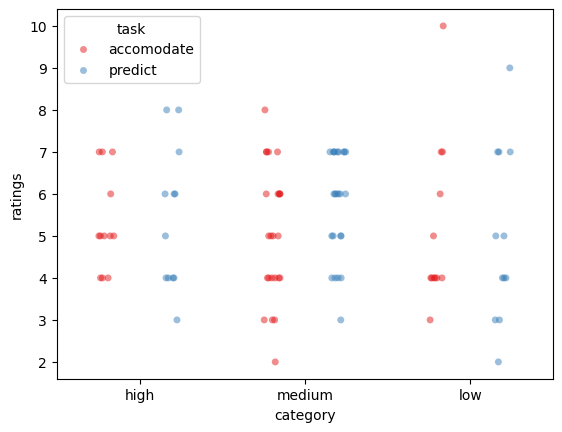

In [ ]:
sns.stripplot(data=df_average, x='category', y='ratings', hue='task', 
              palette='Set1', dodge=True, jitter=True, color='black', alpha=0.5)

In [ ]:
print(df_average.head(20))

    participant  ratings        task category  num_features_relevant
0             1      6.0  accomodate     high                      1
1             1      5.0  accomodate   medium                      1
2             1      3.0  accomodate      low                      1
3             1      5.0  accomodate   medium                      1
4             1      5.0  accomodate   medium                      1
5             1      7.0  accomodate     high                      1
6             1      4.0  accomodate      low                      1
7             1      4.0  accomodate   medium                      1
8             2      5.0  accomodate   medium                      2
9             2      3.0  accomodate   medium                      2
10            2      5.0  accomodate     high                      2
11            2      7.0  accomodate      low                      2
12            2      7.0  accomodate     high                      2
13            2      5.0  accomoda

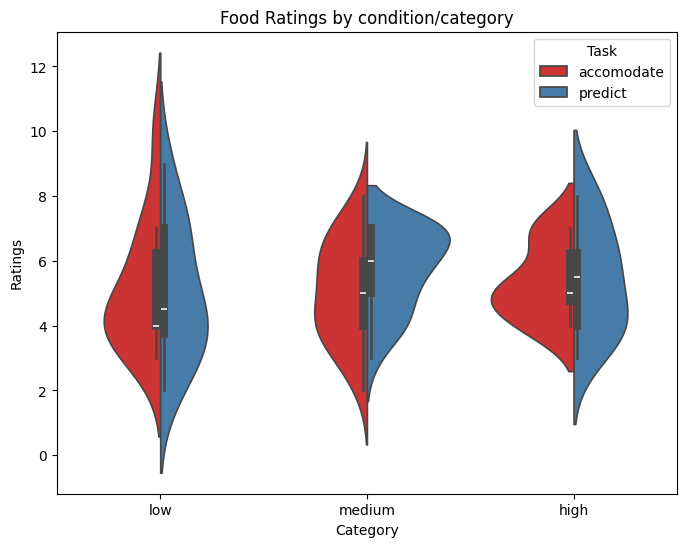

In [ ]:
order = ['low', 'medium', 'high']
# Violin plot: ratings by category, separated by task
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_average,
    x='category',       # x-axis: categories
    y='ratings',        # y-axis: ratings
    hue='task',         # split by task
    split=True,         # split the violins by task
    palette='Set1',
    inner='box',    # show box plot of data inside
    order = order
)

plt.ylabel('Ratings')
plt.xlabel('Category')
plt.title('Food Ratings by condition/category')
plt.legend(title='Task')
#plt.savefig(f'{study}Plots/ViolinRatings.png', bbox_inches='tight')
plt.show()

In [ ]:
def decode_rel(rel_values):
    """
    rel_values: Series of lists of rel codes
    """

    flat_vals = []
    for v in rel_values:
        if isinstance(v, list):
            flat_vals.extend(v)

    flat_vals = pd.Series(flat_vals).dropna().unique()

    if len(flat_vals) == 0:
        return pd.Series({'feature_relevance': np.nan})

    # irrelevant: only I-codes
    if all(v.startswith('I') for v in flat_vals):
        return pd.Series({'feature_relevance': 'irrelevant'})

    # relevant: contains R or L
    if any(v.startswith(('R', 'L')) for v in flat_vals):
        return pd.Series({'feature_relevance': 'relevant'})

    raise ValueError(f"Unexpected rel codes: {flat_vals}")


feature_relevance_rows = []

for (cond, task), subdf in df_combined.groupby(['conditionOrder', 'task']):
    for feat in ['tail', 'color', 'shape']:
        relevance = decode_rel(subdf[f'training_{feat}'])

        feature_relevance_rows.append({
            'conditionOrder': cond,
            'task': task,
            'feature_dimension': feat,
            'feature_relevance': relevance
        })

df_feature_relevance = pd.DataFrame(feature_relevance_rows)
print(df_feature_relevance)

    conditionOrder        task feature_dimension  \
0                1  accomodate              tail   
1                1  accomodate             color   
2                1  accomodate             shape   
3                1     predict              tail   
4                1     predict             color   
5                1     predict             shape   
6                2  accomodate              tail   
7                2  accomodate             color   
8                2  accomodate             shape   
9                2     predict              tail   
10               2     predict             color   
11               2     predict             shape   
12               3  accomodate              tail   
13               3  accomodate             color   
14               3  accomodate             shape   
15               3     predict              tail   
16               3     predict             color   
17               3     predict             shape   
18          

In [ ]:
features = ['shape', 'color', 'tail']
long_rows = []

for _, row in df_combined.iterrows():
    for feat in features:
        long_rows.append({
            'participant': row['participant'],
            'conditionOrder': row['conditionOrder'],
            'task': row['task'],
            'feature_dimension': feat,

            'discrete': row[f'{feat}_discrete_slider.response'],
            'direction': row[f'{feat}_direction_slider.response'],
            'continuous': row[f'{feat}_continuous_slider.response'],
        })

df_long = pd.DataFrame(long_rows)
print(df_long.head(10))

   participant  conditionOrder        task feature_dimension discrete  \
0            1               4  accomodate             shape      Yes   
1            1               4  accomodate             color       No   
2            1               4  accomodate              tail       No   
3            2               1  accomodate             shape       No   
4            2               1  accomodate             color      Yes   
5            2               1  accomodate              tail      Yes   
6            3               3  accomodate             shape      Yes   
7            3               3  accomodate             color      Yes   
8            3               3  accomodate              tail      Yes   
9            4               2  accomodate             shape      Yes   

       direction  continuous  
0         Square         5.0  
1            NaN         NaN  
2            NaN         NaN  
3            NaN         NaN  
4           Blue         4.0  
5  Having 

In [ ]:
df_long = df_long.merge(
    df_feature_relevance,
    on=['conditionOrder', 'task', 'feature_dimension'],
    how='left'
)
print(df_long.head(21))

    participant  conditionOrder        task feature_dimension discrete  \
0             1               4  accomodate             shape      Yes   
1             1               4  accomodate             color       No   
2             1               4  accomodate              tail       No   
3             2               1  accomodate             shape       No   
4             2               1  accomodate             color      Yes   
5             2               1  accomodate              tail      Yes   
6             3               3  accomodate             shape      Yes   
7             3               3  accomodate             color      Yes   
8             3               3  accomodate              tail      Yes   
9             4               2  accomodate             shape      Yes   
10            4               2  accomodate             color      Yes   
11            4               2  accomodate              tail      Yes   
12            5               2     pr